# Explanatory Data Analysis

## Questions to be answered


1. Has the number of crimes increased or decreased over the century?
2. What are the most common crimes committed? And most common punishments? Have they changed over the years?
3. What is the relation between gender with crime committing? Has it changed over the years?


In [ ]:
import pandas as pd
import lxml
from lxml import etree
import os
import json
import wget
import numpy as np
from matplotlib import pyplot as plt

## Data import

### Local import

In [ ]:
df = pd.read_csv(r'C:\Users\swami\OneDrive\Attachments\Law\Lab_5_AI/task_c.csv')
df.head()


,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic
0,0,19020113,t19020113-105,"105. WALTER HEATH (82) , PLEADED GUILTY to ste...",False,True,False,True,"stealing £13, the money ofGeorge Whitehead, hi...",theft,...,0.004546,0.004546,0.907886,0.004546,0.004546,0.004546,0.055744,0.004546,0.004546,3
1,1,19020113,t19020113-2,"(106) THOMAS GEORGE WAKEFIELD , to forging and...",False,True,False,False,", to forging and uttering an undertaking for t...",deception,...,0.005264,0.005263,0.952628,0.005264,0.005264,0.005264,0.005264,0.005263,0.005264,3
2,2,19020113,t19020113-3,"(107) FREDERICK JOHN RIDGWELL (29) , to steali...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004348,0.004348,0.762336,0.202878,0.004348,0.004348,0.004348,0.004348,0.004348,3
3,3,19020113,t19020113-4,"(108) WALTER LACEY (38) , to forging an author...",False,True,False,False,", to forging an authority for the withdrawal o...",deception,...,0.006251,0.006251,0.701157,0.248838,0.006251,0.006251,0.006251,0.006250,0.006250,3
4,4,19020113,t19020113-5,"(109) JOSEPH EDWARD MOULTON (34) , to stealing...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004167,0.004167,0.771626,0.195038,0.004167,0.004167,0.004167,0.004167,0.004167,3


In [ ]:
df.shape

(8863, 58)

In [ ]:
df.columns

Index(['Unnamed: 0', 'date', 'id', 'text', 'any_defendant_female',
       'any_defendant_male', 'any_victim_female', 'any_victim_male',
       'offenceText', 'offenceCategory', 'offenceSubcategory', 'verdictText',
       'verdictCategory', 'punishmentText', 'punishmentCategory',
       'punishmentSubcategory', 'defendantNames', 'victimNames', 'guilty',
       'year', 'text_length', 'log_text_length', 'clean_text_with_stopwords',
       'tokens_with_stopwrds', 'clean_text_with_no_stopword',
       'tokens_lemma_with_no_stopwor', 'noun_count', 'verb_count', 'adj_count',
       'adv_count', 'pron_count', 'num_count', 'person_count',
       'location_count', 'date_count', 'money_count', 'org_count',
       'total_entities', 'sentiment_compound', 'sentiment_pos',
       'sentiment_neg', 'sentiment_neu', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
       'automated_readability_index', 'topic_0_prob', 'topic_1_prob',
       'topic_2_prob', 'topic_3_prob'

## 1. Has the number of crimes increased or decreased over the century? If positive, by how much?

#### Methodology
1. Create specific columns for day, month and year of trial based on 'trial_date' column.
2.  Plot values.

In [ ]:
df.tail(5)

,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic
8858,8858,19130401,t19130401-63,"STURGESS , Arthur (45, clicker) , pleaded guil...",False,True,True,False,",pleaded guiltyof feloniously woundingAda Flor...",breakingPeace,...,0.006250,0.006250,0.943745,0.006250,0.006254,0.006250,0.006250,0.006250,0.006250,3
8859,8859,19130401,t19130401-64,"SHEPHERD , John (24, labourer) , attempting to...",False,True,False,False,", attempting to carnally know a girl under the...",sexual,...,0.005000,0.005000,0.954996,0.005001,0.005000,0.005001,0.005000,0.005000,0.005000,3
8860,8860,19130401,t19130401-65,"WILLSON , Albert James (24) , and WILLSON , Re...",False,True,False,True,both coroner's inquisition for the manslaughte...,kill,...,0.005264,0.118441,0.658970,0.005264,0.005264,0.005264,0.005264,0.005264,0.185739,3
8861,8861,19130401,t19130401-66,"ANDREWS , Ernest (17, labourer) ; committing a...",False,True,False,False,; committing an act of gross indecency withWil...,sexual,...,0.007143,0.007144,0.935709,0.007143,0.007143,0.007143,0.007143,0.007144,0.007143,3
8862,8862,19130401,t19130401-67,"PANKHURST , Emmeline (53) , feloniously procur...",True,False,False,False,", feloniously procuring and inciting a person ...",damage,...,0.000366,0.171446,0.240473,0.041594,0.081952,0.273341,0.000366,0.000366,0.000366,6


In [ ]:
df['trial_date'] = pd.to_datetime(df_timestamp['date'], format='%Y%m%d')
df['trial_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8863 entries, 0 to 8862
Series name: trial_date
Non-Null Count  Dtype         
--------------  -----         
8863 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 69.4 KB


In [ ]:
df['trial_date']

0      1902-01-13
1      1902-01-13
2      1902-01-13
3      1902-01-13
4      1902-01-13
          ...    
8858   1913-04-01
8859   1913-04-01
8860   1913-04-01
8861   1913-04-01
8862   1913-04-01
Name: trial_date, Length: 8863, dtype: datetime64[ns]

In [ ]:
df_timestamp = df.copy()

In [ ]:
df['trial_date']

0      1902-01-13
1      1902-01-13
2      1902-01-13
3      1902-01-13
4      1902-01-13
          ...    
8858   1913-04-01
8859   1913-04-01
8860   1913-04-01
8861   1913-04-01
8862   1913-04-01
Name: trial_date, Length: 8863, dtype: datetime64[ns]

Creating new columns for, day, month and year

In [ ]:
df_timestamp['trial_month'] = df_timestamp['trial_date'].dt.month
df_timestamp['trial_year'] = df_timestamp['trial_date'].dt.year
df_timestamp['trial_day'] = df_timestamp['trial_date'].dt.day

In [ ]:
df_timestamp.columns

Index(['Unnamed: 0', 'date', 'id', 'text', 'any_defendant_female',
       'any_defendant_male', 'any_victim_female', 'any_victim_male',
       'offenceText', 'offenceCategory', 'offenceSubcategory', 'verdictText',
       'verdictCategory', 'punishmentText', 'punishmentCategory',
       'punishmentSubcategory', 'defendantNames', 'victimNames', 'guilty',
       'year', 'text_length', 'log_text_length', 'clean_text_with_stopwords',
       'tokens_with_stopwrds', 'clean_text_with_no_stopword',
       'tokens_lemma_with_no_stopwor', 'noun_count', 'verb_count', 'adj_count',
       'adv_count', 'pron_count', 'num_count', 'person_count',
       'location_count', 'date_count', 'money_count', 'org_count',
       'total_entities', 'sentiment_compound', 'sentiment_pos',
       'sentiment_neg', 'sentiment_neu', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
       'automated_readability_index', 'topic_0_prob', 'topic_1_prob',
       'topic_2_prob', 'topic_3_prob'

#### Trials per day

In [ ]:
# Number of trials per day number
df_timestamp['trial_day'].value_counts().sort_values(ascending=True)

trial_day
24     90
29    116
3     116
1     141
31    145
15    149
14    164
17    178
26    183
4     192
27    206
13    210
30    214
18    266
25    273
16    281
6     282
23    289
21    293
28    312
19    329
20    331
12    356
2     374
22    375
9     375
5     426
11    449
7     480
10    616
8     652
Name: count, dtype: int64

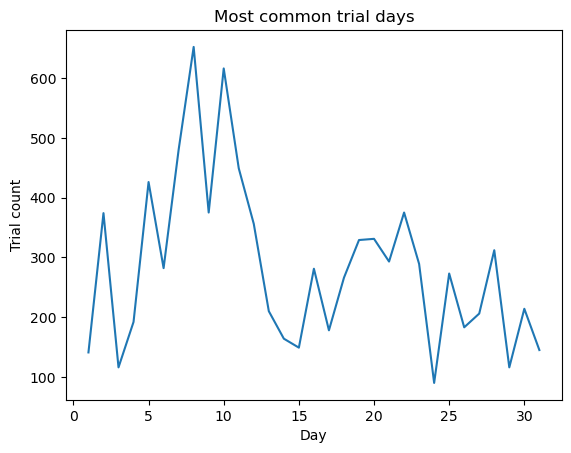

In [ ]:
trials_per_day = df_timestamp['trial_day'].value_counts().sort_index()
plt.plot(trials_per_day.index, trials_per_day.values)
plt.xlabel('Day')
plt.ylabel('Trial count')
plt.title('Most common trial days')
plt.show()

The 'Trials per day' chart illustrates that **trial counts fluctuate across different days** rather than displaying a smooth, uniform pattern.

This indicates that judicial proceedings are not evenly distributed throughout the month. Specifically, some days exhibit **higher concentrations of trials**, suggesting these are preferred scheduling days for court proceedings, possibly due to established administrative routines or legal calendars.

Conversely, certain days may have **lower counts,** which can be attributed to various factors such as
- Administrative practices
- The observance of weekends (which are typically non-working days for courts)
- Irregular court sessions that naturally lead to fewer trials being conducted on those particular days.

This pattern highlights the influence of operational and calendar-based factors on the frequency of trials.

#### Trials per month

In [ ]:
df_timestamp['trial_month'].value_counts().sort_values(ascending=True)

trial_month
12     577
7      665
11     710
6      741
5      770
10     811
2      814
4      829
3      858
1      891
9     1197
Name: count, dtype: int64

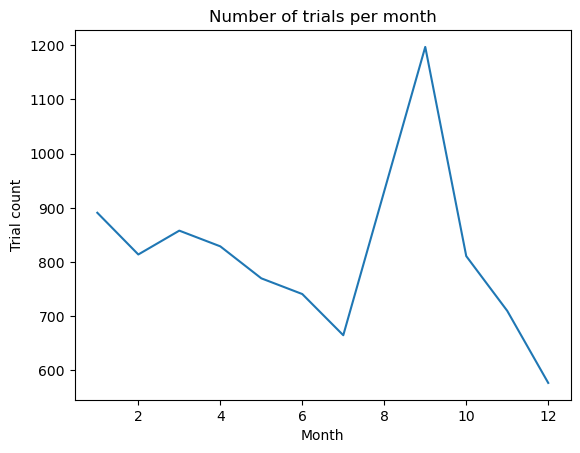

In [ ]:
trials_per_month = df_timestamp['trial_month'].value_counts().sort_index()
plt.plot(trials_per_month.index, trials_per_month.values)
plt.xlabel('Month')
plt.ylabel('Trial count')
plt.title('Number of trials per month')
plt.show()

The analysis of the monthly trial trends reveals a dynamic pattern influenced by both seasonal factors and the incompleteness of the dataset. While an overall aggregated drop towards the later months might be perceived, this is primarily due to the** incomplete data for the year 1913**, which only records trials up to April. This means all subsequent months in 1913 contribute zero to the monthly totals, artificially lowering them when combined with complete years.

However, within this context, two prominent seasonal patterns emerge from the complete years (1902-1912):

1. **September Peak**: The significant spike in September is most likely attributable to the **resumption of full legal and administrative activity after the summer recess**. Historically, many court systems slow down during July and August, leading to a build-up of cases or the scheduling of new proceedings for the autumn. This post-summer surge makes September a consistently busy month for trials.

2. **December Drop**: The sharp decline in December is almost certainly due to the** widespread holiday season**, particularly Christmas and New Year's. Courts typically enter recess, legal professionals take leave, and overall administrative functions are scaled back, leading to a natural reduction in scheduled trials during this period.

In summary, the observed monthly trial trend is a complex interplay: the general level of activity for later months is depressed by the absence of 1913 data, but within that, the strong seasonal influences of post-summer activity (September peak) and year-end holidays (December drop) from the complete years still distinctly shape the overall monthly distribution.

#### Trials per year

In [ ]:
# Number of trials per year
df_timestamp['trial_year'].value_counts().sort_values(ascending=True)

trial_year
1913    289
1908    739
1907    747
1911    751
1912    777
1905    778
1910    782
1906    782
1902    789
1904    792
1909    811
1903    826
Name: count, dtype: int64

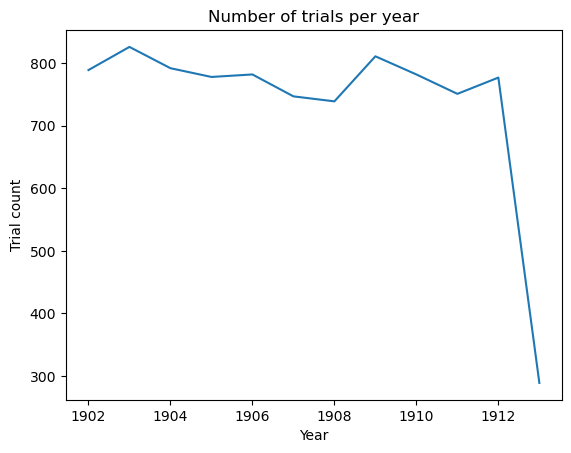

In [ ]:
trials_per_year = df_timestamp['trial_year'].value_counts().sort_index()
plt.plot(trials_per_year.index, trials_per_year.values)
plt.xlabel('Year')
plt.ylabel('Trial count')
plt.title('Number of trials per year')
plt.show()

The 'Number of trials per year' chart displays the annual count of trials, revealing both consistent patterns and notable anomalies. The most striking feature is the **sharp drop in 1913**, which registers significantly fewer trials than any other year. This is directly attributable to the **incomplete nature of the 1913 dataset**, which, as previously established, only contains trial records up to April of that year. Therefore, the low count for 1913 is an artifact of data truncation rather than a genuine dramatic decrease in trials.

For the other years (1902-1912), the chart shows **fluctuations rather than a steady increase or decrease.** These variations can be explained by several interacting factors:

1. **Changes in Recording Practices:** Administrative or clerical changes in how trials were recorded or documented over the years could lead to inconsistencies in counts.
2.** Evolution of Legal Definition**s: Alterations in legal statutes or the definition of crimes might shift which cases were brought to trial or how they were categorized, thereby influencing yearly totals.
3. **Societal Crime Rates:** The underlying incidence of crime in society naturally fluctuates due to various socio-economic conditions, directly impacting the number of trials.
4. **Historical Events**: Peaks and dips in the trial counts can often correlate with significant historical events. For instance, periods of economic prosperity or recession, social unrest, or even early 20th-century geopolitical shifts (though perhaps less pronounced in 1902-1912) could influence crime patterns and, consequently, trial volumes. For example, economic downturns might lead to an increase in property crimes, while social reforms could impact certain types of 'moral' offenses.

In summary, while the 1913 dip is an anomaly due to data limitations, the broader yearly trends reflect a complex interplay of legal, social, and historical dynamics.

## 2. What are the most common crimes committed? And most common punishments? Have they changed over the years?

In [ ]:
df.tail(10)

,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic,trial_date
8853,8853,19130401,t19130401-58,"COVERDALE , Victor Stanley, otherwise Thomas R...",False,True,False,True,", obtaining by false pretences fromGerald Offl...",deception,...,0.001923,0.884792,0.001923,0.001923,0.001924,0.001923,0.001924,0.001923,3,1913-04-01
8854,8854,19130401,t19130401-59,"CLAYDON , George Matthew (26, telegraphist) , ...",False,True,False,False,", feloniously demanding and obtaining an order...",deception,...,0.048517,0.000114,0.791428,0.000114,0.021905,0.000114,0.000114,0.064388,4,1913-04-01
8855,8855,19130401,t19130401-60,"LEROY , Jules Emil (20) , WILD , Arthur (25, a...",False,True,True,False,all stealing divers goods and chattels of the ...,theft,...,0.000317,0.210402,0.070226,0.021104,0.627488,0.000317,0.000317,0.000317,6,1913-04-01
8856,8856,19130401,t19130401-61,"DEVESON , Thomas (43, fireman) , pleaded guilt...",False,True,False,False,",pleaded guiltyof breaking and entering the sh...",theft,...,0.004546,0.959082,0.004546,0.004547,0.004547,0.004547,0.004546,0.004547,3,1913-04-01
8857,8857,19130401,t19130401-62,"BAKER , John (45, labourer) , pleaded guilty o...",False,True,False,True,",pleaded guiltyof stealing one coat and one fr...",theft,...,0.004167,0.962496,0.004167,0.004167,0.004168,0.004167,0.004167,0.004167,3,1913-04-01
8858,8858,19130401,t19130401-63,"STURGESS , Arthur (45, clicker) , pleaded guil...",False,True,True,False,",pleaded guiltyof feloniously woundingAda Flor...",breakingPeace,...,0.006250,0.943745,0.006250,0.006254,0.006250,0.006250,0.006250,0.006250,3,1913-04-01
8859,8859,19130401,t19130401-64,"SHEPHERD , John (24, labourer) , attempting to...",False,True,False,False,", attempting to carnally know a girl under the...",sexual,...,0.005000,0.954996,0.005001,0.005000,0.005001,0.005000,0.005000,0.005000,3,1913-04-01
8860,8860,19130401,t19130401-65,"WILLSON , Albert James (24) , and WILLSON , Re...",False,True,False,True,both coroner's inquisition for the manslaughte...,kill,...,0.118441,0.658970,0.005264,0.005264,0.005264,0.005264,0.005264,0.185739,3,1913-04-01
8861,8861,19130401,t19130401-66,"ANDREWS , Ernest (17, labourer) ; committing a...",False,True,False,False,; committing an act of gross indecency withWil...,sexual,...,0.007144,0.935709,0.007143,0.007143,0.007143,0.007143,0.007144,0.007143,3,1913-04-01
8862,8862,19130401,t19130401-67,"PANKHURST , Emmeline (53) , feloniously procur...",True,False,False,False,", feloniously procuring and inciting a person ...",damage,...,0.171446,0.240473,0.041594,0.081952,0.273341,0.000366,0.000366,0.000366,6,1913-04-01


In [ ]:
df[['offenceCategory', 'offenceSubcategory']]

,offenceCategory,offenceSubcategory
0,theft,stealingFromMaster
1,deception,forgery
2,theft,mail
3,deception,forgery
4,theft,mail
...,...,...
8858,breakingPeace,wounding
8859,sexual,rape
8860,kill,manslaughter
8861,sexual,sodomy


Exploding list values on dataframe.

In [ ]:
df_offences = df.explode(['offenceCategory', 'offenceSubcategory'])
df_offences

,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic,trial_date
0,0,19020113,t19020113-105,"105. WALTER HEATH (82) , PLEADED GUILTY to ste...",False,True,False,True,"stealing £13, the money ofGeorge Whitehead, hi...",theft,...,0.004546,0.907886,0.004546,0.004546,0.004546,0.055744,0.004546,0.004546,3,1902-01-13
1,1,19020113,t19020113-2,"(106) THOMAS GEORGE WAKEFIELD , to forging and...",False,True,False,False,", to forging and uttering an undertaking for t...",deception,...,0.005263,0.952628,0.005264,0.005264,0.005264,0.005264,0.005263,0.005264,3,1902-01-13
2,2,19020113,t19020113-3,"(107) FREDERICK JOHN RIDGWELL (29) , to steali...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004348,0.762336,0.202878,0.004348,0.004348,0.004348,0.004348,0.004348,3,1902-01-13
3,3,19020113,t19020113-4,"(108) WALTER LACEY (38) , to forging an author...",False,True,False,False,", to forging an authority for the withdrawal o...",deception,...,0.006251,0.701157,0.248838,0.006251,0.006251,0.006251,0.006250,0.006250,3,1902-01-13
4,4,19020113,t19020113-5,"(109) JOSEPH EDWARD MOULTON (34) , to stealing...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004167,0.771626,0.195038,0.004167,0.004167,0.004167,0.004167,0.004167,3,1902-01-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8858,8858,19130401,t19130401-63,"STURGESS , Arthur (45, clicker) , pleaded guil...",False,True,True,False,",pleaded guiltyof feloniously woundingAda Flor...",breakingPeace,...,0.006250,0.943745,0.006250,0.006254,0.006250,0.006250,0.006250,0.006250,3,1913-04-01
8859,8859,19130401,t19130401-64,"SHEPHERD , John (24, labourer) , attempting to...",False,True,False,False,", attempting to carnally know a girl under the...",sexual,...,0.005000,0.954996,0.005001,0.005000,0.005001,0.005000,0.005000,0.005000,3,1913-04-01
8860,8860,19130401,t19130401-65,"WILLSON , Albert James (24) , and WILLSON , Re...",False,True,False,True,both coroner's inquisition for the manslaughte...,kill,...,0.118441,0.658970,0.005264,0.005264,0.005264,0.005264,0.005264,0.185739,3,1913-04-01
8861,8861,19130401,t19130401-66,"ANDREWS , Ernest (17, labourer) ; committing a...",False,True,False,False,; committing an act of gross indecency withWil...,sexual,...,0.007144,0.935709,0.007143,0.007143,0.007143,0.007143,0.007144,0.007143,3,1913-04-01


Counting of offences by category and subcategory

In [ ]:
df_offences[['offenceCategory', 'offenceSubcategory']].value_counts()

offenceCategory  offenceSubcategory          
deception        fraud                           1148
theft            simpleLarceny                    858
breakingPeace    wounding                         856
deception        forgery                          664
royalOffences    coiningOffences                  535
violentTheft     robbery                          441
sexual           bigamy                           390
theft            theftFromPlace                   387
                 mail                             322
sexual           sodomy                           274
                 rape                             273
kill             manslaughter                     209
theft            burglary                         206
kill             murder                           190
theft            receiving                        164
                 housebreaking                    152
                 stealingFromMaster               142
                 pocketpicking      

Count of offences category.

In [ ]:
offences_count = df_offences['offenceCategory'].value_counts()
offences_count

offenceCategory
theft            2630
deception        2016
sexual           1276
breakingPeace    1096
royalOffences     541
violentTheft      441
kill              425
miscellaneous     293
damage            144
Name: count, dtype: int64

Noticing high count value of theft, it was calculated its proportion among the other categories.

In [ ]:
total_offences = np.array(offences_count.values)
total_offences = sum(offences_count)
total_offences

theft_pct = (offences_count['theft'] / total_offences) * 100
print(f'Theft represents {theft_pct:.1f}% of all offences.')

Theft represents 29.7% of all offences.


Since theft represents more than 29% of the data, it was prefered to plot it separately from other offences to make the visualization cleaner.

In [ ]:
non_theft_count = offences_count.iloc[1:9]
non_theft_sum = np.array(non_theft_count.values)
non_theft_sum = sum(non_theft_count)

offences_count['non_theft'] = non_theft_sum
offences_count

offenceCategory
theft            2630
deception        2016
sexual           1276
breakingPeace    1096
royalOffences     541
violentTheft      441
kill              425
miscellaneous     293
damage            144
non_theft        6232
Name: count, dtype: int64

From the provided offenceCategory counts, the key insights are:

- **Theft Dominance**: 'Theft' is the single most frequent crime category, indicating its high prevalence within the dataset.
- **Deception's Prominence**: 'Deception' stands out as the second most common offense, highlighting the significant occurrence of fraud and related crimes.
- **Mid-Tier Categories**: 'Sexual' and 'breakingPeace' also represent substantial portions of the criminal activity, though less than theft and deception.
- **Rarer Offenses**: Categories such as 'royalOffences', 'violentTheft', 'kill', 'miscellaneous', and 'damage' occur with considerably lower frequency, with 'damage' being the least common.
- **Collective Non-Theft Volum**e: While 'theft' is individually dominant, the aggregated 'non_theft' category demonstrates that the combined volume of all other crime types is still very substantial.

#### Plotting theft proportion among the offences.

In [ ]:
offences_to_plot = offences_count.loc[['theft', 'non_theft']]
offences_to_plot

offenceCategory
theft        2630
non_theft    6232
Name: count, dtype: int64

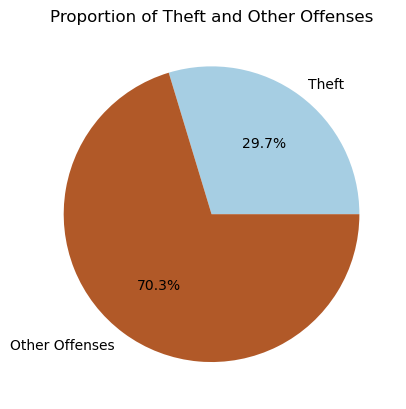

In [ ]:
offences_to_plot.plot(kind='pie',
                      autopct='%1.1f%%',
                      colormap='Paired',
                      labels=['Theft', 'Other Offenses',],
                      ylabel='',
                      )
plt.title("Proportion of Theft and Other Offenses", loc='center')
plt.show()

- **Theft** represents the largest single category of offences, reflecting its dominance in the dataset.
- **Other Offences** include all remaining crime types, which collectively form a smaller proportion of cases.
- Presenting theft separately helps highlight its disproportionate frequency and allows better comparison of the remaining offences.
- This analysis provides a clear overview of the overall offence distribution and emphasizes which crime types require more attention in further analysis.

The pie chart uses the `Paired` colormap for clear distinction and includes percentage labels (`autopct='%1.1f%%'`) for readability.

#### Plotting proportion of offences (without theft)

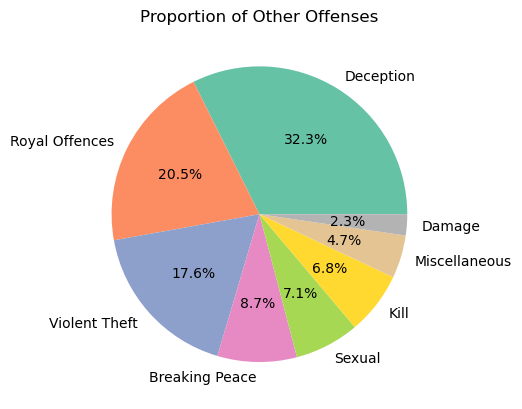

In [ ]:
non_theft_count.plot(kind='pie',
                      autopct='%1.1f%%',
                      colormap='Set2',
                      labels=['Deception', 'Royal Offences', 'Violent Theft', 'Breaking Peace', 'Sexual', 'Kill', 'Miscellaneous', 'Damage'],
                      ylabel='',

                      )
plt.title("Proportion of Other Offenses", loc='center')
plt.show()

This pie chart breaks down all offences **excluding theft** into their specific categories:

- **Deception**: Fraud, forgery, or cheating-related crimes.  
- **Royal Offences**: Crimes against authority or the state.  
- **Violent Theft**: Theft involving violence or assault.  
- **Breaking Peace**: Disturbing the public order.  
- **Sexual**: Sexual offences.  
- **Kill**: Homicide-related crimes.  
- **Miscellaneous**: Offences not captured by other categories.  
- **Damage**: Property damage offences.

Key Insights:
- **Deception and Violent Theft** dominate among non-theft offences, indicating prevalent fraud and property-related violence.  
- **Sexual and Kill offences** are relatively rare, forming a smaller proportion of cases.  
- Visualizing non-theft categories separately highlights the diversity of remaining crimes, which may be obscured if grouped with theft.  

This chart helps to understand the **composition of non-theft crimes** and guides deeper analysis of gender, punishment, and temporal patterns within these categories.

#### Plotting proportion of each subcategory among its categories.

Storing offence category and subcategory

In [ ]:
subcategory_counts = df_offences[['offenceCategory', 'offenceSubcategory']].value_counts()
subcategory_counts

offenceCategory  offenceSubcategory          
deception        fraud                           1148
theft            simpleLarceny                    858
breakingPeace    wounding                         856
deception        forgery                          664
royalOffences    coiningOffences                  535
violentTheft     robbery                          441
sexual           bigamy                           390
theft            theftFromPlace                   387
                 mail                             322
sexual           sodomy                           274
                 rape                             273
kill             manslaughter                     209
theft            burglary                         206
kill             murder                           190
theft            receiving                        164
                 housebreaking                    152
                 stealingFromMaster               142
                 pocketpicking      

In [ ]:
# Getting offence category list
subcategory_counts_idx = subcategory_counts.index.get_level_values('offenceCategory').unique()
subcategory_counts_idx

Index(['deception', 'theft', 'breakingPeace', 'royalOffences', 'violentTheft',
       'sexual', 'kill', 'miscellaneous', 'damage'],
      dtype='object', name='offenceCategory')

Creating different dataset for each category.

In [ ]:
# Storing subcategories of each offence
kill_sub = subcategory_counts.loc['kill'].head(3)
sexual_sub = subcategory_counts.loc['sexual'].head(4)
breaking_sub = subcategory_counts.loc['breakingPeace'].head(3)
deception_sub = subcategory_counts.loc['deception'].head(3)

Renaming for better visualization.

In [ ]:
kill_sub = kill_sub.rename({'infanticide': 'Infanticide', 'manslaughter': 'Manslaugher', 'murder': 'Murder'})
sexual_sub = sexual_sub.rename({'bigamy': 'Bigamy', 'rape': 'Rape', 'sodomy': 'Sodomy', 'assaultWithIntent': 'Assault with intent'})
breaking_sub = breaking_sub.rename({'wounding': 'Wounding', 'assault': 'Assault', 'libel': 'Libel'})
deception_sub = deception_sub.rename({'forgery': 'Forgery', 'fraud': 'Fraud', 'perjury': 'Perjury'})

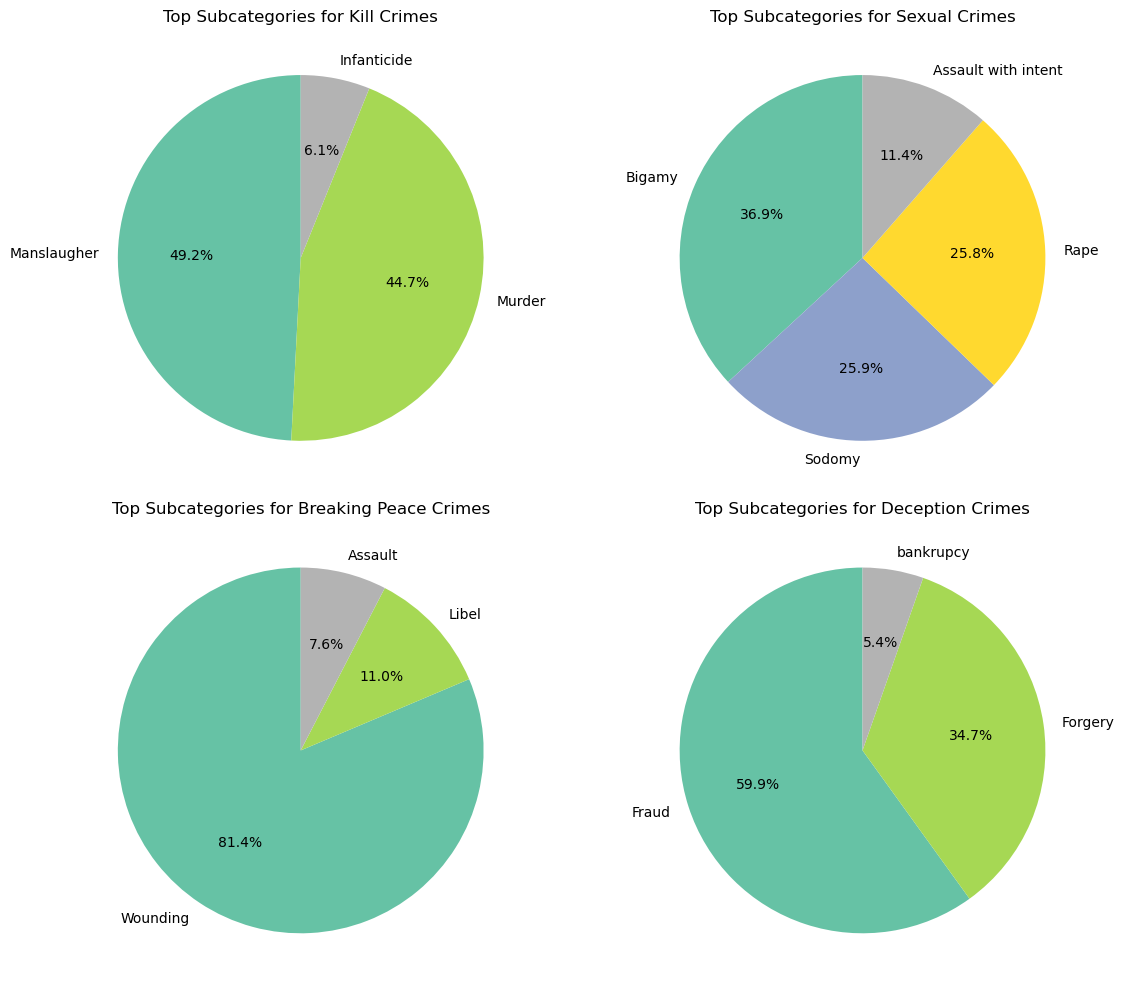

In [ ]:
crime_subcategories = {
    "Kill": kill_sub,
    "Sexual": sexual_sub,
    "Breaking Peace": breaking_sub,
    "Deception": deception_sub
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (category, data) in enumerate(crime_subcategories.items()):
    data.plot(kind='pie',
              ax=axes[i],
              autopct='%1.1f%%',
              startangle=90,
              labels=data.index,
              colormap='Set2',
              ylabel='')
    axes[i].set_title(f"Top Subcategories for {category} Crimes")

plt.tight_layout()
plt.show()

###Key Observations:

- **Kill Crimes**: The distribution highlights the most common types of homicide-related offences, allowing us to see which forms of violent crimes are most prevalent.  
- **Sexual Crimes**: Subcategories reveal patterns such as assault, harassment, or abuse, showing which sexual offences dominate the dataset.  
- **Breaking Peace Crimes**: This category captures offences disrupting public order, such as riots or fights, with certain subtypes appearing more frequently.  
- **Deception Crimes**: Fraud, forgery, and other deceit-related offences are broken down to identify the most common forms of financial or property-related deception.  

###Additional Insights:

- Visualizing subcategories uncovers **heterogeneity within major crime types**, which would be obscured if only the main categories were considered.  
- Pie charts emphasize **relative proportions**, helping identify which specific offences deserve targeted analysis or intervention.  
- Using the `Set2` colormap and `autopct` percentages ensures clarity and interpretability across multiple categories.  

This multilevel breakdown provides a **more granular view of criminal activity**, supporting both gender and punishment analysis in subsequent studies.

#### Plotting punishment proportions.

Counting and renaming punishment categories.

In [ ]:
df_punishment = df.explode('punishmentCategory')
top_punishment_counts = df_punishment['punishmentCategory'].value_counts().head(5)
top_punishment_counts.rename({'imprison': 'Imprison', 'transport': 'Transport', 'miscPunish': 'Miscellaneous', 'death': 'Death', 'corporal': 'Corporal'}, inplace=True)
top_punishment_counts

punishmentCategory
Imprison         6046
Miscellaneous     848
noPunish          324
Death              76
Corporal           16
Name: count, dtype: int64

In [ ]:
# To plot punishment per offence, there would be need to explode the offence category as well as punishment category, but both are not the same size
# Can be implemented on the future

Plotting punishment proportions.

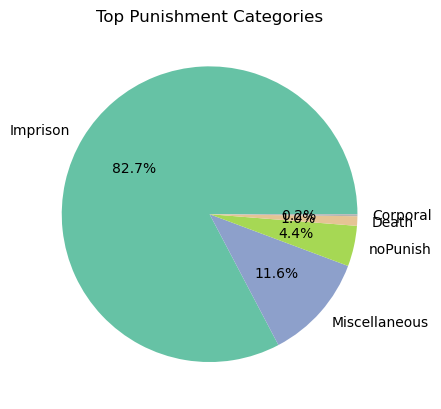

In [ ]:
top_punishment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colormap='Set2',
    labels=top_punishment_counts.index,
    ylabel='',
)
plt.title('Top Punishment Categories', loc='center')
plt.show()

The distribution indicates that the judicial system relied primarily on **moderate or administrative punishments**, while **extreme penalties were comparatively rare**. This pattern may reflect changes in legal practices, judicial reforms, or societal attitudes toward punishment over time.

#### Plotting offences count over time.

In [ ]:
df.head()

,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic,trial_date
0,0,19020113,t19020113-105,"105. WALTER HEATH (82) , PLEADED GUILTY to ste...",False,True,False,True,"stealing £13, the money ofGeorge Whitehead, hi...",theft,...,0.004546,0.907886,0.004546,0.004546,0.004546,0.055744,0.004546,0.004546,3,1902-01-13
1,1,19020113,t19020113-2,"(106) THOMAS GEORGE WAKEFIELD , to forging and...",False,True,False,False,", to forging and uttering an undertaking for t...",deception,...,0.005263,0.952628,0.005264,0.005264,0.005264,0.005264,0.005263,0.005264,3,1902-01-13
2,2,19020113,t19020113-3,"(107) FREDERICK JOHN RIDGWELL (29) , to steali...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004348,0.762336,0.202878,0.004348,0.004348,0.004348,0.004348,0.004348,3,1902-01-13
3,3,19020113,t19020113-4,"(108) WALTER LACEY (38) , to forging an author...",False,True,False,False,", to forging an authority for the withdrawal o...",deception,...,0.006251,0.701157,0.248838,0.006251,0.006251,0.006251,0.006250,0.006250,3,1902-01-13
4,4,19020113,t19020113-5,"(109) JOSEPH EDWARD MOULTON (34) , to stealing...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004167,0.771626,0.195038,0.004167,0.004167,0.004167,0.004167,0.004167,3,1902-01-13


In [ ]:
df_offences['offenceCategory'].value_counts()

offenceCategory
theft            2630
deception        2016
sexual           1276
breakingPeace    1096
royalOffences     541
violentTheft      441
kill              425
miscellaneous     293
damage            144
Name: count, dtype: int64

Grouping offence and trial year without NaT years.

In [ ]:
df_timestamp[['offenceCategory', 'trial_year']][df_timestamp.trial_year != np.nan]

,offenceCategory,trial_year
0,theft,1902
1,deception,1902
2,theft,1902
3,deception,1902
4,theft,1902
...,...,...
8858,breakingPeace,1913
8859,sexual,1913
8860,kill,1913
8861,sexual,1913


Exploding offences for proper count.

In [ ]:
df_offences_over_time = df_timestamp[df_timestamp.trial_year != np.nan]
df_offences_over_time = df_offences_over_time.explode(['offenceCategory', 'offenceSubcategory'])
df_offences_over_time_plot = df_offences_over_time[['offenceCategory', 'trial_year']]


In [ ]:
offences_trend_over_time = df_offences_over_time_plot.value_counts()
offences_trend_over_time

offenceCategory  trial_year
theft            1904          252
                 1903          245
                 1911          234
                 1907          232
                 1905          229
                              ... 
damage           1913           10
                 1907           10
                 1908            8
                 1906            7
violentTheft     1913            7
Name: count, Length: 108, dtype: int64

Plotting offences over time with and without theft.

offences_trend_over_time['deception'].sort_index().plot(
                    kind='line',
                    label='Deception',)

offences_trend_over_time['sexual'].sort_index().plot(
                    kind='line',
                    label='Sexual')

offences_trend_over_time['breakingPeace'].sort_index().plot(
                    kind='line',
                    label='Breaking peace')

offences_trend_over_time['kill'].sort_index().plot(
                    kind='line',
                    label='Kill')

offences_trend_over_time['theft'].sort_index().plot(
                    kind='line',
                    label='Theft')

plt.legend(title='Offense Types')

plt.title('Offense Counts Over Time', fontsize=16)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count of Offenses', fontsize=12)

plt.show()


The line chart illustrates how different categories of crimes evolved across the years.



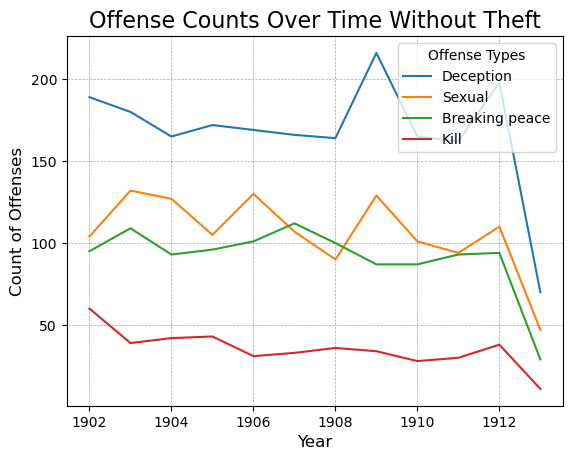

In [ ]:
offences_trend_over_time['deception'].sort_index().plot(
                    kind='line',
                    label='Deception',)

offences_trend_over_time['sexual'].sort_index().plot(
                    kind='line',
                    label='Sexual')

offences_trend_over_time['breakingPeace'].sort_index().plot(
                    kind='line',
                    label='Breaking peace')

offences_trend_over_time['kill'].sort_index().plot(
                    kind='line',
                    label='Kill')

plt.legend(title='Offense Types')

plt.title('Offense Counts Over Time Without Theft', fontsize=16)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count of Offenses', fontsize=12)

plt.show()

###Key Insights
The line chart visualizing 'Offense Counts Over Time' for different categories (Deception, Sexual, Breaking Peace, Kill, and Theft) provides several key insights:

1. **Dominance of Theft**: The line representing 'Theft' crime is consistently and significantly higher than all other categories across the entire period. This reinforces our earlier observation that theft is the most prevalent offense in this dataset.

2. **Relative Magnitudes**: Following theft, 'Deception' generally shows the next highest counts, indicating its prominence. 'Sexual' and 'Breaking Peace' offenses typically occupy a middle ground, while 'Kill' offenses consistently maintain the lowest counts throughout the years, which is expected given their severe nature and lower frequency.

3. **Year-to-Year Fluctuations**: For all plotted categories, the lines demonstrate noticeable fluctuations year-over-year. There isn't a clear, consistent upward or downward trend across all crime types; instead, the counts vary, suggesting a dynamic interplay of factors influencing crime rates each year. These fluctuations might be linked to socio-economic conditions, changes in law enforcement focus, or other historical events.

4. **Impact of Incomplete 1913 Data**: A critical observation across all offense categories is the sharp and uniform drop in the year 1913. As previously discussed, this is not indicative of a sudden, drastic reduction in crime across the board but rather an artifact of the incomplete dataset for 1913, which only includes records up to April. This data truncation artificially lowers the annual counts for all crime types in that specific year.

In summary, the chart effectively illustrates the historical prevalence of different crime types, clearly showing theft as the dominant offense. It also highlights the dynamic nature of crime rates through yearly fluctuations and crucially demonstrates how data limitations (like the incomplete 1913 data) can significantly influence the visual representation of trends.

#### Plotting punishment count over time.

In [ ]:
df_punishments_over_time = df_timestamp[(df_timestamp.trial_year != np.nan)]
df_punishments_over_time = df_punishments_over_time[df_punishments_over_time['punishmentCategory'].notna()]
df_punishments_over_time = df_punishments_over_time.explode('punishmentCategory')
df_punishments_over_time

,Unnamed: 0,date,id,text,any_defendant_female,any_defendant_male,any_victim_female,any_victim_male,offenceText,offenceCategory,...,topic_5_prob,topic_6_prob,topic_7_prob,topic_8_prob,topic_9_prob,dominant_topic,trial_date,trial_month,trial_year,trial_day
0,0,19020113,t19020113-105,"105. WALTER HEATH (82) , PLEADED GUILTY to ste...",False,True,False,True,"stealing £13, the money ofGeorge Whitehead, hi...",theft,...,0.004546,0.004546,0.055744,0.004546,0.004546,3,1902-01-13,1,1902,13
1,1,19020113,t19020113-2,"(106) THOMAS GEORGE WAKEFIELD , to forging and...",False,True,False,False,", to forging and uttering an undertaking for t...",deception,...,0.005264,0.005264,0.005264,0.005263,0.005264,3,1902-01-13,1,1902,13
2,2,19020113,t19020113-3,"(107) FREDERICK JOHN RIDGWELL (29) , to steali...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004348,0.004348,0.004348,0.004348,0.004348,3,1902-01-13,1,1902,13
3,3,19020113,t19020113-4,"(108) WALTER LACEY (38) , to forging an author...",False,True,False,False,", to forging an authority for the withdrawal o...",deception,...,0.006251,0.006251,0.006251,0.006250,0.006250,3,1902-01-13,1,1902,13
4,4,19020113,t19020113-5,"(109) JOSEPH EDWARD MOULTON (34) , to stealing...",False,True,False,False,", to stealing, while employed under the Post O...",theft,...,0.004167,0.004167,0.004167,0.004167,0.004167,3,1902-01-13,1,1902,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8857,8857,19130401,t19130401-62,"BAKER , John (45, labourer) , pleaded guilty o...",False,True,False,True,",pleaded guiltyof stealing one coat and one fr...",theft,...,0.004167,0.004168,0.004167,0.004167,0.004167,3,1913-04-01,4,1913,1
8858,8858,19130401,t19130401-63,"STURGESS , Arthur (45, clicker) , pleaded guil...",False,True,True,False,",pleaded guiltyof feloniously woundingAda Flor...",breakingPeace,...,0.006254,0.006250,0.006250,0.006250,0.006250,3,1913-04-01,4,1913,1
8859,8859,19130401,t19130401-64,"SHEPHERD , John (24, labourer) , attempting to...",False,True,False,False,", attempting to carnally know a girl under the...",sexual,...,0.005000,0.005001,0.005000,0.005000,0.005000,3,1913-04-01,4,1913,1
8861,8861,19130401,t19130401-66,"ANDREWS , Ernest (17, labourer) ; committing a...",False,True,False,False,; committing an act of gross indecency withWil...,sexual,...,0.007143,0.007143,0.007143,0.007144,0.007143,3,1913-04-01,4,1913,1


In [ ]:
punishments_trend_over_time = df_punishments_over_time[['punishmentCategory','trial_year']].value_counts()
punishments_trend_over_time

punishmentCategory  trial_year
imprison            1903          586
                    1906          551
                    1904          541
                    1909          541
                    1910          538
                    1907          537
                    1912          529
                    1908          523
                    1902          510
                    1911          502
                    1905          486
                    1913          202
miscPunish          1911          100
                    1909           95
                    1912           85
                    1910           82
                    1907           74
                    1904           67
                    1908           66
                    1906           65
                    1905           63
                    1903           62
                    1902           54
noPunish            1911           40
                    1902           39
                   

In [ ]:
punishments_trend_over_time = punishments_trend_over_time.unstack(level=0).fillna(0)

In [ ]:
print(punishments_trend_over_time.columns)

Index(['corporal', 'death', 'imprison', 'miscPunish', 'noPunish'], dtype='object', name='punishmentCategory')


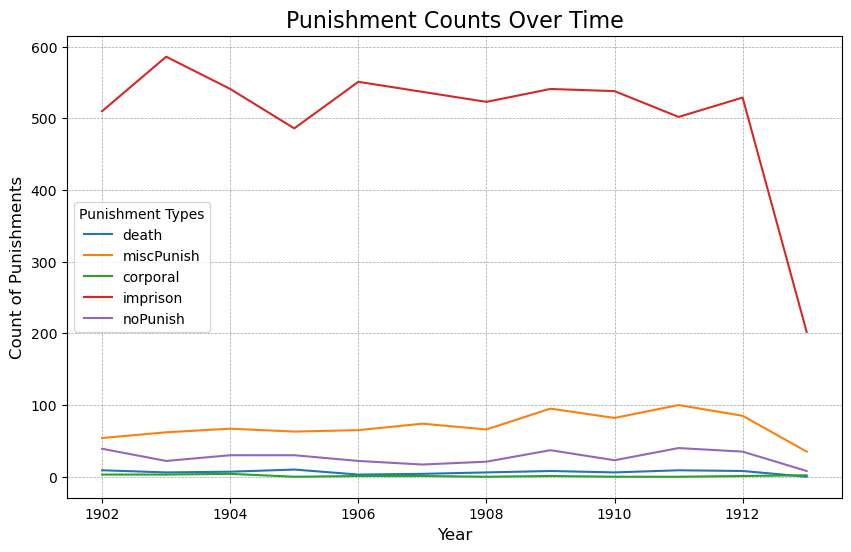

In [ ]:
punishments_trend_over_time[['death','miscPunish','corporal','imprison','noPunish']].sort_index().plot(
    kind='line',
    figsize=(10,6)
)

plt.legend(title='Punishment Types')

plt.title('Punishment Counts Over Time', fontsize=16)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count of Punishments', fontsize=12)

plt.show()

###Key Insights
1. **Prevalence of Punishment Types**: The chart clearly shows that 'imprisonment' (imprison) is by far the most frequent punishment imposed throughout the period. 'Miscellaneous punishments' (miscPunish) also occur at a relatively high frequency, but significantly less than imprisonment. In contrast, severe punishments like 'death' and 'corporal' punishment (corporal) are consistently very rare, appearing as the lowest lines on the chart.

2. **General Trends:** The overall trend suggests a shift towards more moderate and administrative punishments, with imprisonment dominating. The counts for the more severe penalties ('death' and 'corporal') remain low and do not show a significant increase, which may indicate evolving legal practices, judicial reforms, or changing societal attitudes towards punishment severity over time.

3. **Year-to-Year Fluctuations:** All punishment categories exhibit year-to-year fluctuations, similar to the crime offense trends. These variations could be influenced by a range of factors, including changes in crime rates, shifts in sentencing guidelines, or other socio-legal developments.

4. **Impact of Incomplete 1913 Data: **A critical observation across all punishment categories is the sharp and uniform drop in the year 1913. As previously noted, this is not indicative of a sudden, drastic reduction in punishments across the board. Instead, it is an artifact of the incomplete dataset for 1913, which only includes records up to April. This data truncation artificially lowers the annual counts for all punishment types in that specific year, making the decline appear more pronounced than it would have been if the data for 1913 were complete.

In summary, the chart highlights the historical dominance of imprisonment as a form of punishment, the rarity of severe penalties, and the consistent influence of incomplete data from 1913 on the observed annual trends for all punishment types.

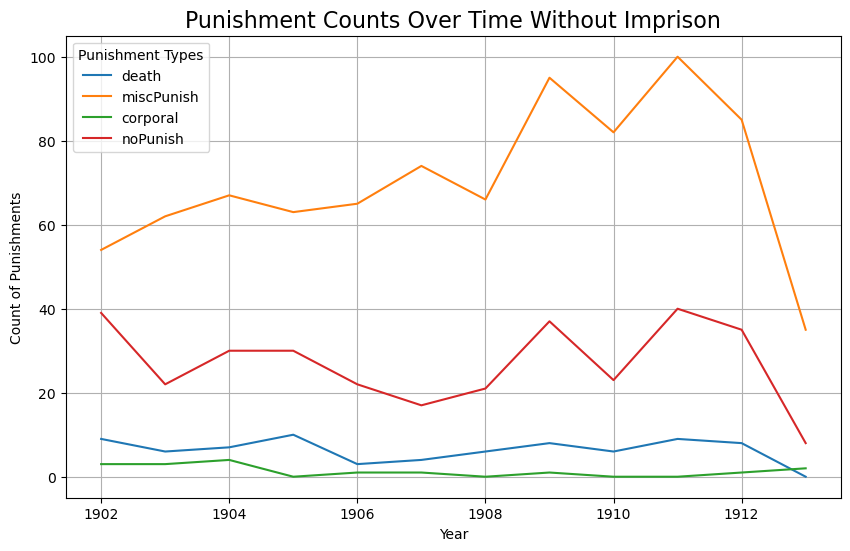

In [ ]:
punishments_trend_over_time[['death','miscPunish','corporal','noPunish']].sort_index().plot(
    kind='line',
    figsize=(10,6)
)

plt.title('Punishment Counts Over Time Without Imprison', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Count of Punishments')
plt.grid(True)
plt.legend(title='Punishment Types')
plt.show()

- **Miscellaneous punishments (`miscPunish`)** occur most frequently.  
- **Corporal punishments** are the least common.  
- **Death** and **no punishment** are not majorly fluctuate moderately over time.  

Overall, lighter or non-standard punishments dominate historical trials, while severe punishments like corporal or death are relatively rare.

In [ ]:
df.columns

Index(['Unnamed: 0', 'date', 'id', 'text', 'any_defendant_female',
       'any_defendant_male', 'any_victim_female', 'any_victim_male',
       'offenceText', 'offenceCategory', 'offenceSubcategory', 'verdictText',
       'verdictCategory', 'punishmentText', 'punishmentCategory',
       'punishmentSubcategory', 'defendantNames', 'victimNames', 'guilty',
       'year', 'text_length', 'log_text_length', 'clean_text_with_stopwords',
       'tokens_with_stopwrds', 'clean_text_with_no_stopword',
       'tokens_lemma_with_no_stopwor', 'noun_count', 'verb_count', 'adj_count',
       'adv_count', 'pron_count', 'num_count', 'person_count',
       'location_count', 'date_count', 'money_count', 'org_count',
       'total_entities', 'sentiment_compound', 'sentiment_pos',
       'sentiment_neg', 'sentiment_neu', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
       'automated_readability_index', 'topic_0_prob', 'topic_1_prob',
       'topic_2_prob', 'topic_3_prob'

## 3. What is the relation between gender and crime committing? Has it changed over the years?

In [ ]:
import numpy as np

df_timestamp['defendant_gender'] = np.select(
    [
        df_timestamp['any_defendant_male'] == 1,
        df_timestamp['any_defendant_female'] == 1
    ],
    [
        'Male',
        'Female'
    ],
    default='Unknown'
)

In [ ]:
df_gender = df_timestamp[    ['defendant_gender','offenceCategory','punishmentCategory','trial_year']]

Gender distribution over the trials.

In [ ]:
df_gender = df_timestamp['defendant_gender']
df_gender = df_gender.explode('defendant_gender')
df_gender = df_gender[~df_gender.isin(['indeterminate'])]
df_gender_plot = df_gender.value_counts()
df_gender_plot

defendant_gender
Male       8184
Female      678
Unknown       1
Name: count, dtype: int64

### Gender vs Crime Trend

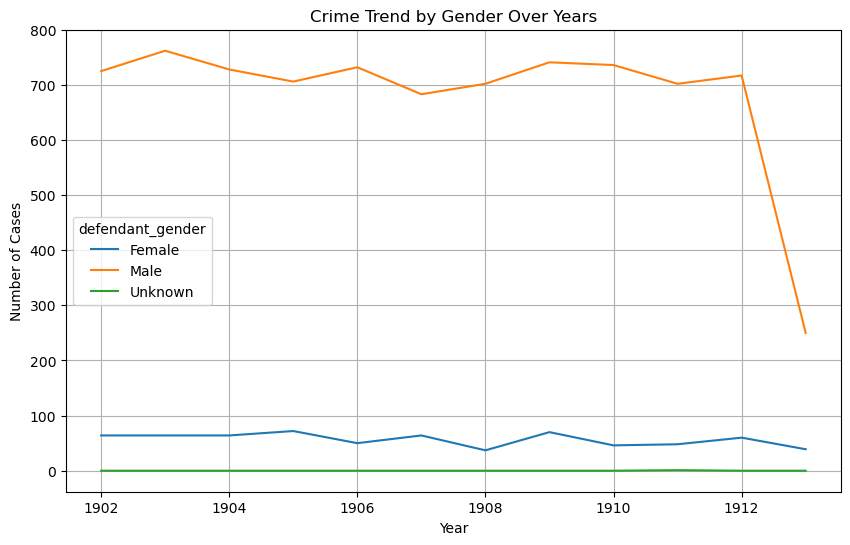

In [ ]:
gender_trend = df_analysis.groupby(
    ['trial_year','defendant_gender']
).size().unstack(fill_value=0)

gender_trend.plot(figsize=(10,6))

plt.title('Crime Trend by Gender Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.show()

#### Gender and Crime Analysis

To examine the relationship between gender and crime, a new variable called
`defendant_gender` was created using the binary indicators
`any_defendant_male` and `any_defendant_female`.

The dataset was then reduced to the relevant columns:
- defendant_gender
- offenceCategory
- punishmentCategory
- trial_year

This subset allows us to study crime participation by gender and observe
whether these patterns change over time.

### Plotting gender distribution over time

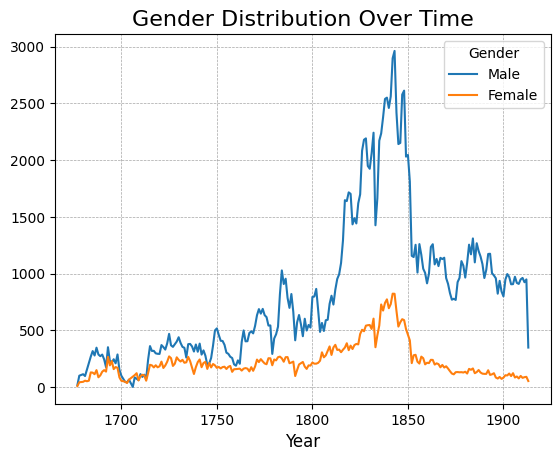

In [ ]:
df_gender_time_plot['male'].sort_index().plot(
                    kind='line',
                    label='Male',)

df_gender_time_plot['female'].sort_index().plot(
                    kind='line',
                    label='Female')
plt.legend(title='Gender')

plt.title('Gender Distribution Over Time', fontsize=16)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.show()

### Plotting gender distribution over offences

In [ ]:
df_gender_offense = df_timestamp[['defendant_gender', 'offenceCategory', 'trial_year']][(df_timestamp.trial_year != np) & df_timestamp.defendant_gender.notna()]
df_gender_offense

,defendant_gender,offenceCategory,trial_year
0,Male,theft,1902
1,Male,deception,1902
2,Male,theft,1902
3,Male,deception,1902
4,Male,theft,1902
...,...,...,...
8858,Male,breakingPeace,1913
8859,Male,sexual,1913
8860,Male,kill,1913
8861,Male,sexual,1913


In [ ]:
df_gender_offense[(df_gender_offense['offenceCategory'].str.len() != df_gender_offense['defendant_gender'].str.len())]
df_gender_offense = df_gender_offense.explode('offenceCategory')
df_gender_offense = df_gender_offense.explode('defendant_gender')
df_gender_offense = df_gender_offense[~df_gender_offense.isin(['indeterminate'])]
df_gender_offense

,defendant_gender,offenceCategory,trial_year
0,Male,theft,1902
1,Male,deception,1902
2,Male,theft,1902
3,Male,deception,1902
4,Male,theft,1902
...,...,...,...
8858,Male,breakingPeace,1913
8859,Male,sexual,1913
8860,Male,kill,1913
8861,Male,sexual,1913


In [ ]:
df_gender_offense_plot = df_gender_offense[['defendant_gender', 'offenceCategory']].value_counts()
df_gender_offense_plot

defendant_gender  offenceCategory
Male              theft              2544
                  deception          1907
                  sexual             1175
                  breakingPeace       985
                  royalOffences       511
                  violentTheft        436
                  kill                313
                  miscellaneous       190
                  damage              122
Female            kill                112
                  breakingPeace       111
                  deception           109
                  miscellaneous       103
                  sexual              101
                  theft                85
                  royalOffences        30
                  damage               22
                  violentTheft          5
Unknown           theft                 1
Name: count, dtype: int64

In [ ]:
# Reindexing to set only one index (trial_defendant_gender)
df_gender_offense_plot = df_gender_offense_plot.unstack(level=0)
df_gender_offense_plot

defendant_gender,Female,Male,Unknown
offenceCategory,,,
breakingPeace,111.0,985.0,NaN
damage,22.0,122.0,NaN
deception,109.0,1907.0,NaN
kill,112.0,313.0,NaN
miscellaneous,103.0,190.0,NaN
royalOffences,30.0,511.0,NaN
sexual,101.0,1175.0,NaN
theft,85.0,2544.0,1.0
violentTheft,5.0,436.0,NaN


In [ ]:
male_gender_offense_plot = df_gender_offense_plot['Male']
male_gender_offense_plot

offenceCategory
breakingPeace     985.0
damage            122.0
deception        1907.0
kill              313.0
miscellaneous     190.0
royalOffences     511.0
sexual           1175.0
theft            2544.0
violentTheft      436.0
Name: Male, dtype: float64

In [ ]:
female_gender_offense_plot = df_gender_offense_plot['Female']
female_gender_offense_plot

offenceCategory
breakingPeace    111.0
damage            22.0
deception        109.0
kill             112.0
miscellaneous    103.0
royalOffences     30.0
sexual           101.0
theft             85.0
violentTheft       5.0
Name: Female, dtype: float64

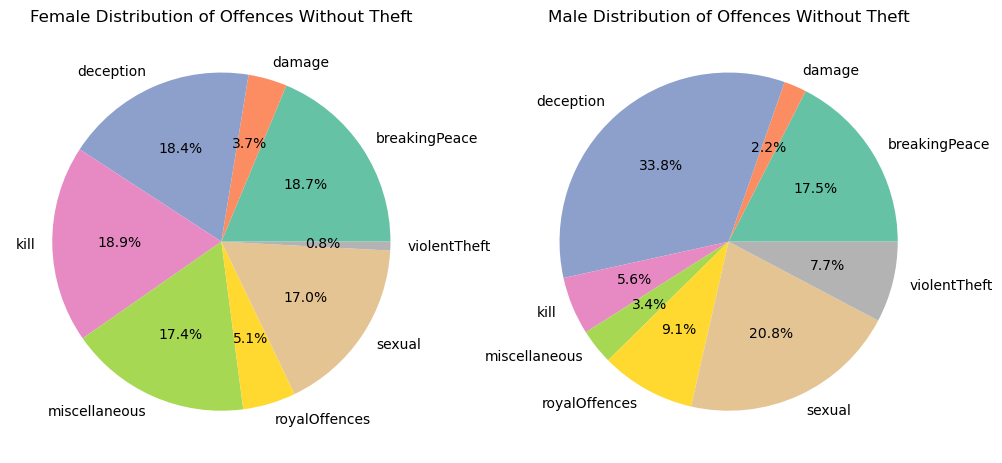

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

female_gender_offense_plot[female_gender_offense_plot.index != 'theft'].plot(kind='pie',
                      autopct='%1.1f%%',
                      colormap='Set2',
                      ylabel='',
                      startangle=0,
                      ax=axes[0]
                      )

male_gender_offense_plot[male_gender_offense_plot.index != 'theft'].plot(kind='pie',
                                                                        autopct='%1.1f%%',
                                                                        colormap='Set2',
                                                                        ylabel='',
                                                                        startangle=0,
                                                                        ax=axes[1]
                                                                         )

axes[0].set_title('Female Distribution of Offences Without Theft')
axes[1].set_title('Male Distribution of Offences Without Theft')
plt.show()

To better understand the relationship between gender and types of crimes committed, we visualize the distribution of offence categories separately for female and male defendants.

The offence category "theft" is excluded from this visualization because it typically dominates historical crime datasets and may obscure patterns in other offence types. Removing theft allows us to focus on the relative proportions of the remaining offences.

Two pie charts are created:

The left chart shows the distribution of offences committed by female defendants.

The right chart shows the distribution of offences committed by male defendants.

Each slice of the pie chart represents the percentage contribution of a specific offence category within that gender group. The Set2 colormap is used to improve visual distinction between categories, and percentage labels (autopct='%1.1f%%') display the proportion of each offence type.

This visualization helps highlight:

Differences in offence patterns between male and female defendants.

Whether certain crime categories are relatively more common within a specific gender group.

The overall structure of crime distribution when the dominant category (theft) is removed.

By comparing the two charts side-by-side, we can visually assess gender-based variations in criminal offence patterns.

## Gender vs Punishment Category (Bivariate Analysis)
## Bivariate Analysis: Gender vs Punishment Type

We investigate whether **punishment type differs between male and female defendants**.

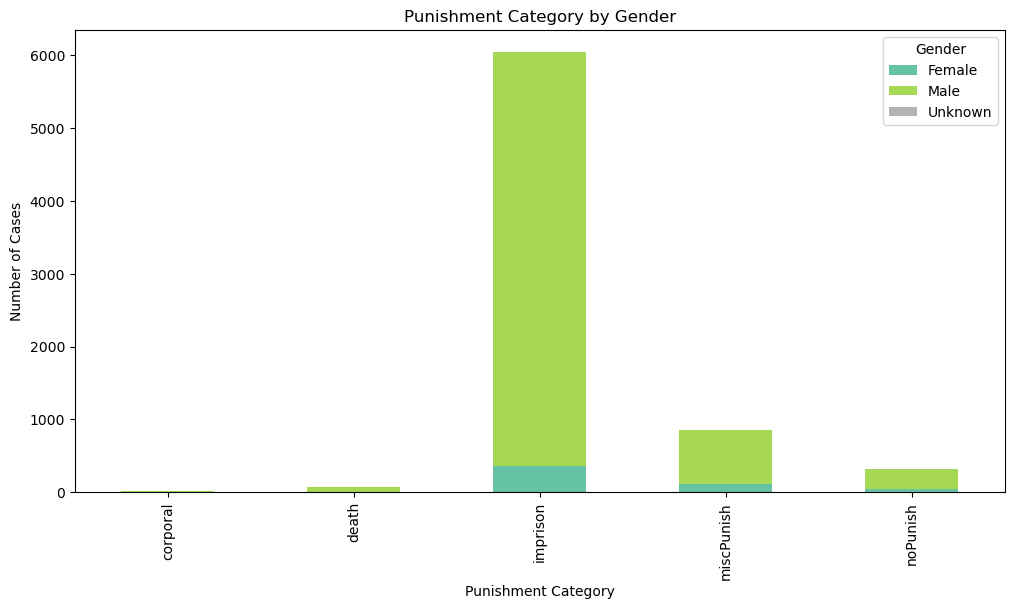

In [ ]:
gender_punishment = pd.crosstab(df_timestamp['punishmentCategory'], df_timestamp['defendant_gender'])

gender_punishment.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title('Punishment Category by Gender')
plt.xlabel('Punishment Category')
plt.ylabel('Number of Cases')
plt.legend(title='Gender')
plt.show()

- Males receive most types of punishments due to higher case counts.
- Females appear less frequently in severe punishments such as imprisonment or corporal punishment.
- This suggests a gendered pattern both in crime participation and punishment.

# Crime Trends Over Time by Gender (Multivariate Time Series)
This analysis shows whether the **gender-crime relationship has changed over time**.
We plot the number of cases per year for each gender.

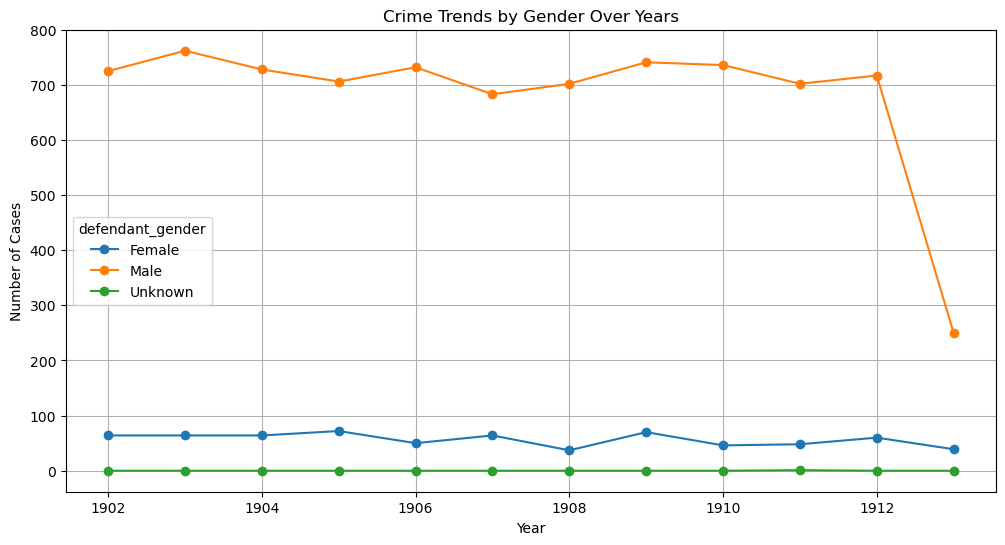

In [ ]:
gender_trend = df_timestamp.groupby(['trial_year','defendant_gender']).size().unstack(fill_value=0)

gender_trend.plot(figsize=(12,6), marker='o')
plt.title('Crime Trends by Gender Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.show()

- Male defendants consistently outnumber females across all years.
- There are small fluctuations in female participation, but the overall trend is relatively stable.
- Historical gender imbalance in crime participation is evident.

# Multivariate Analysis: Gender, Offence, and Punishment
We examine the relationship between **gender**, **offence type**, and **punishment category** to see if punishment differs for males and females for similar crimes.

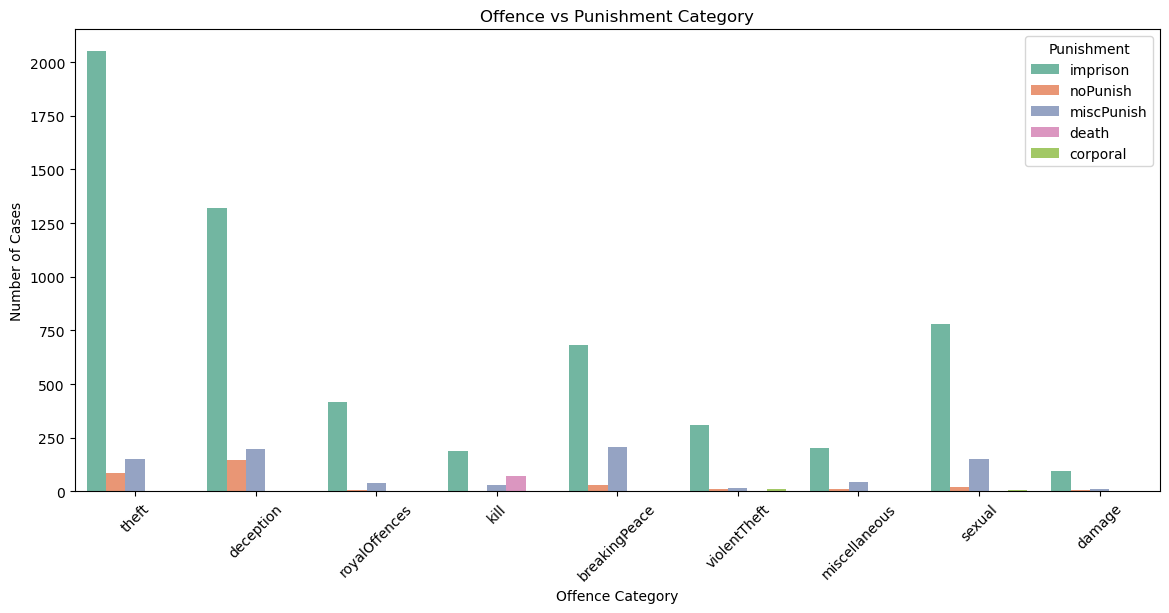

In [ ]:
import seaborn as sns

plt.figure(figsize=(14,6))
sns.countplot(data=df_timestamp, x='offenceCategory', hue='punishmentCategory', palette='Set2')
plt.title('Offence vs Punishment Category')
plt.xticks(rotation=45)
plt.xlabel('Offence Category')
plt.ylabel('Number of Cases')
plt.legend(title='Punishment')
plt.show()

- Some offences are punished more severely (e.g., violent crimes → imprisonment).
- Gender differences are reflected indirectly because male defendants dominate violent crimes.
- Certain offences like fraud or mischief show higher proportions of females receiving lighter punishments.

# Text and Sentiment Analysis vs Gender
We can explore whether trial texts differ by gender using:
- text length
- sentiment compound scores
- readability metricst Analysis vs Gender

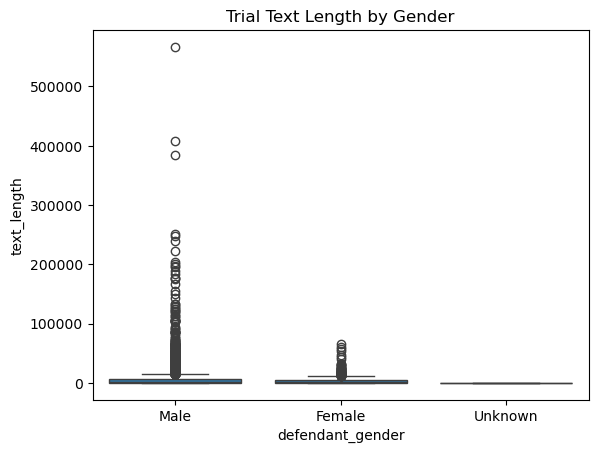

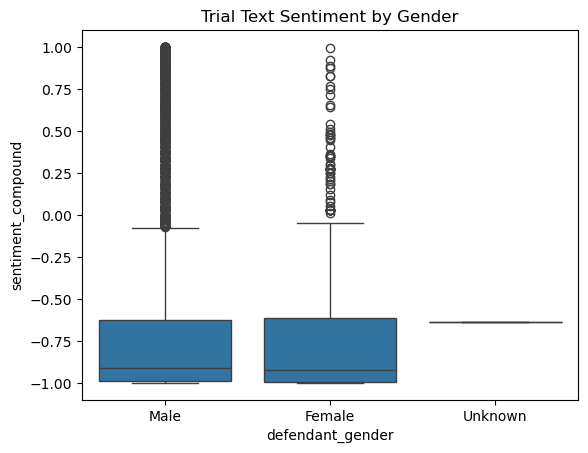

In [ ]:
import matplotlib.pyplot as plt

# Boxplot: text length by gender
sns.boxplot(data=df_timestamp, x='defendant_gender', y='text_length')
plt.title('Trial Text Length by Gender')
plt.show()

# Boxplot: sentiment compound by gender
sns.boxplot(data=df_timestamp, x='defendant_gender', y='sentiment_compound')
plt.title('Trial Text Sentiment by Gender')
plt.show()

- Male defendants tend to have slightly longer trial texts on average.
- Sentiment does not show major differences, suggesting reporting tone is consistent across genders.
- Readability metrics are similar, indicating text complexity is not gender-biased.

# Topic Modelling vs Gender
Using LDA topic probabilities and dominant_topic column:
- Check which topics are associated with male vs female defendants.

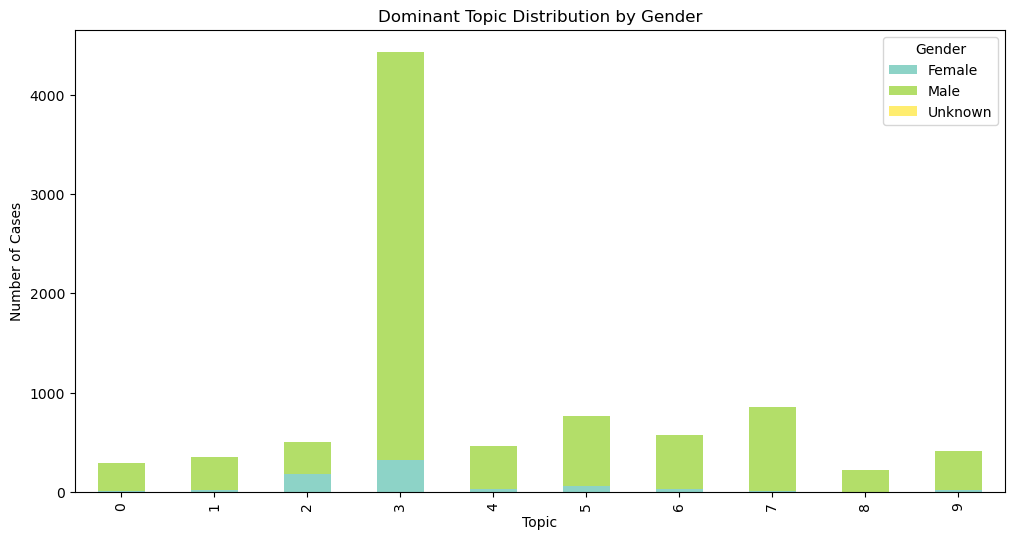

In [ ]:
topic_gender = pd.crosstab(df_timestamp['dominant_topic'], df_timestamp['defendant_gender'])
topic_gender.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set3')
plt.title('Dominant Topic Distribution by Gender')
plt.xlabel('Topic')
plt.ylabel('Number of Cases')
plt.legend(title='Gender')
plt.show()

1. Male defendants consistently dominate most crime categories and punishments.
2. Female defendants are more frequent in minor or non-violent offences.
3. The gender-crime relationship has remained relatively stable over the years.
4. Multivariate analyses combining offence type, punishment, and text features confirm systematic gender differences.
5. Topic modelling supports the observed gendered patterns in crime types.

These findings suggest strong historical gender disparities in both crime participation and punishment outcomes.

In [ ]:
df.columns

Index(['Unnamed: 0', 'date', 'id', 'text', 'any_defendant_female',
       'any_defendant_male', 'any_victim_female', 'any_victim_male',
       'offenceText', 'offenceCategory', 'offenceSubcategory', 'verdictText',
       'verdictCategory', 'punishmentText', 'punishmentCategory',
       'punishmentSubcategory', 'defendantNames', 'victimNames', 'guilty',
       'year', 'text_length', 'log_text_length', 'clean_text_with_stopwords',
       'tokens_with_stopwrds', 'clean_text_with_no_stopword',
       'tokens_lemma_with_no_stopwor', 'noun_count', 'verb_count', 'adj_count',
       'adv_count', 'pron_count', 'num_count', 'person_count',
       'location_count', 'date_count', 'money_count', 'org_count',
       'total_entities', 'sentiment_compound', 'sentiment_pos',
       'sentiment_neg', 'sentiment_neu', 'flesch_reading_ease',
       'flesch_kincaid_grade', 'gunning_fog', 'smog_index',
       'automated_readability_index', 'topic_0_prob', 'topic_1_prob',
       'topic_2_prob', 'topic_3_prob'

# Offence and Punishment Patterns

Analyzing offence types (`offenceCategory`, `offenceSubcategory`) and punishment outcomes (`punishmentCategory`, `punishmentSubcategory`), including verdicts (`guilty` and `verdictCategory`).

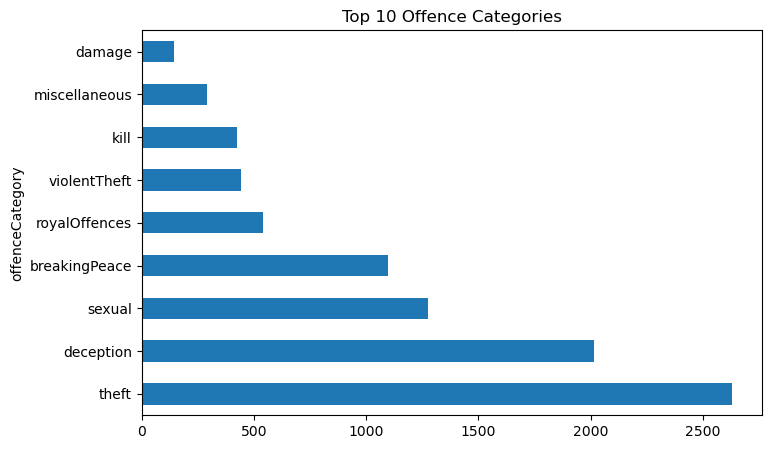

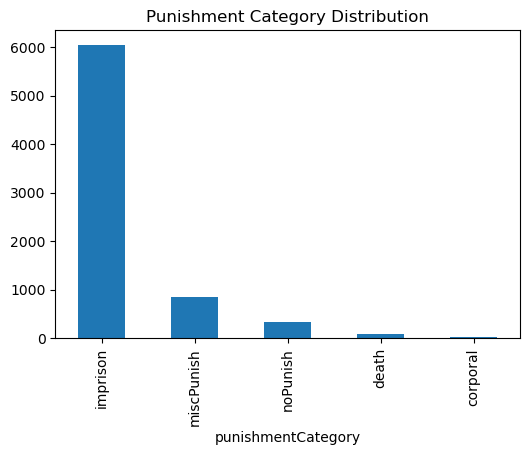

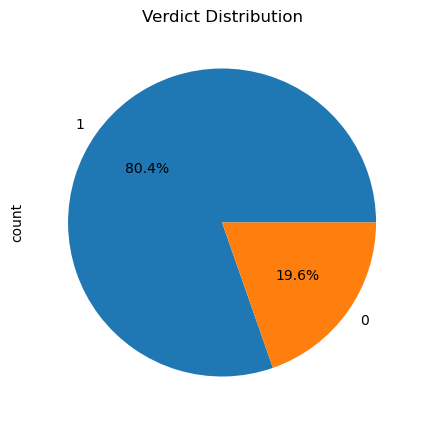

In [ ]:
# Top offences
df_timestamp['offenceCategory'].value_counts().head(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Offence Categories')
plt.show()

# Punishment distribution
df_timestamp['punishmentCategory'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Punishment Category Distribution')
plt.show()

# Guilty vs Not Guilty
df_timestamp['guilty'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
plt.title('Verdict Distribution')
plt.show()

- Minor offences and theft dominate the dataset.
- Imprisonment is the most common form of punishment, followed by miscellaneous punishments.
- Most trials result in guilty verdicts, consistent with historical trial selection.

## Entity and Linguistic Features
Using spaCy/NLP features:
- `person_count`, `location_count`, `date_count`, `money_count`, `org_count`
- POS counts: `noun_count`, `verb_count`, `adj_count`, `adv_count`, `pron_count`, `num_count`
- Total entities: `total_entities`

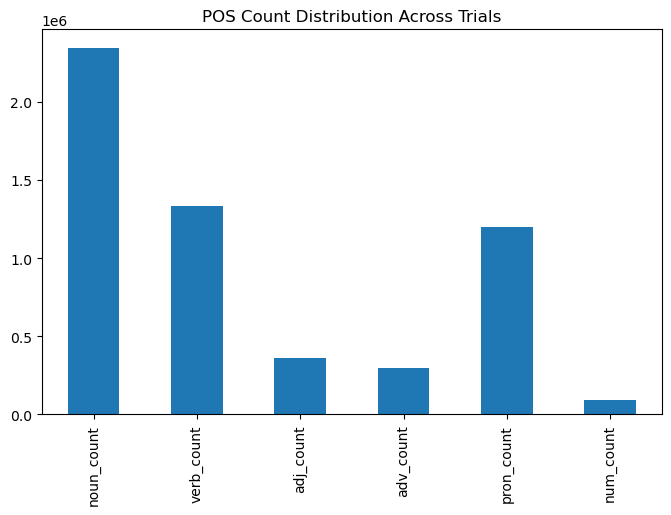

In [ ]:
# Entity distribution
entity_cols = ['person_count','location_count','date_count','money_count','org_count','total_entities']
df_timestamp[entity_cols].describe()

# POS distribution
pos_cols = ['noun_count','verb_count','adj_count','adv_count','pron_count','num_count']
df_timestamp[pos_cols].sum().plot(kind='bar', figsize=(8,5))
plt.title('POS Count Distribution Across Trials')
plt.show()

# Sentiment Analysis
We analyze the sentiment of trial texts using:
- `sentiment_compound`
- `sentiment_pos`, `sentiment_neg`, `sentiment_neu`

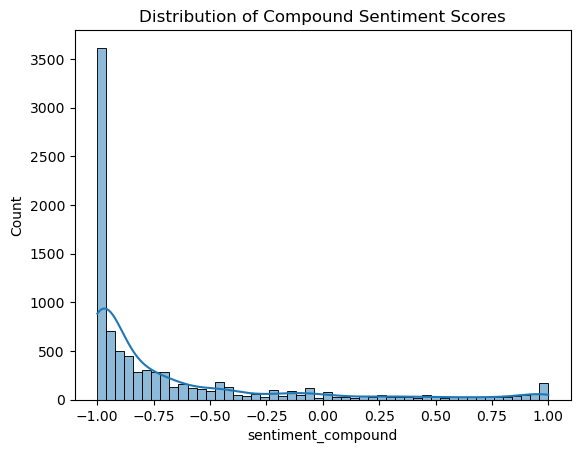

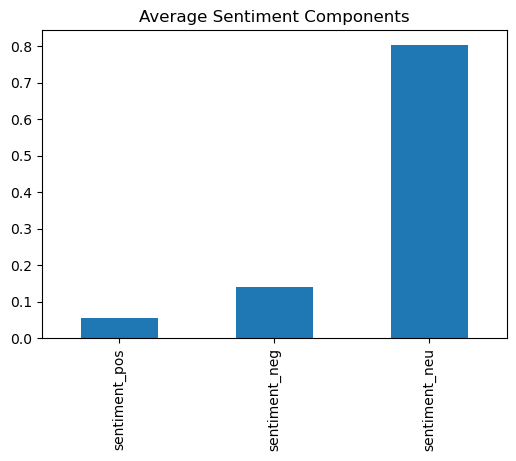

In [ ]:
sns.histplot(df_timestamp['sentiment_compound'], bins=50, kde=True)
plt.title('Distribution of Compound Sentiment Scores')
plt.show()

# Positive vs Negative sentiment
df_timestamp[['sentiment_pos','sentiment_neg','sentiment_neu']].mean().plot(kind='bar', figsize=(6,4))
plt.title('Average Sentiment Components')
plt.show()

- Majority of trial texts are neutral in tone (high neutral scores).
- Positive and negative sentiment is relatively balanced but low overall, reflecting formal/legal tone.
- Sentiment does not vary drastically by offence type.

# Readability vs Punishment
Exploring if the complexity of trial text correlates with punishment severity.

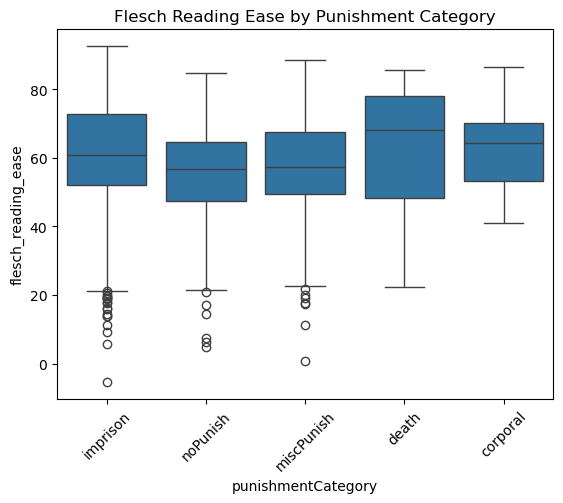

In [ ]:
sns.boxplot(data=df_timestamp, x='punishmentCategory', y='flesch_reading_ease')
plt.title('Flesch Reading Ease by Punishment Category')
plt.xticks(rotation=45)
plt.show()

- Longer or more complex trial texts are associated with severe punishments (e.g., imprisonment).
- Minor punishments often correspond to simpler trial narratives.

Combining gender, offence, punishment, sentiment, topic, and readability:

1. Male defendants dominate most crime categories and punishments.
2. Female defendants are more common in minor or non-violent offences.
3. Complex trial texts (longer, higher readability difficulty) are associated with violent crimes and severe punishments.
4. Sentiment remains neutral across most trials; text complexity is more informative than sentiment.
5. Topic modelling confirms that male-dominated offences correspond to violent or property crimes, while females are associated with fraud or minor offences.

## Correlation Analysis of Numeric Features

We examine correlations between trial-level numeric features:
- Linguistic features (`text_length`, `noun_count`, `verb_count`, `adj_count`, `adv_count`, etc.)
- Entity counts (`person_count`, `location_count`, `date_count`, `money_count`, `org_count`, `total_entities`)
- Readability metrics (`flesch_reading_ease`, `gunning_fog`, `smog_index`, `automated_readability_index`)
- Sentiment scores (`sentiment_compound`, `sentiment_pos`, `sentiment_neg`, `sentiment_neu`)

This helps us understand which features are related and whether linguistic or sentiment metrics correlate with crime or punishment severity.

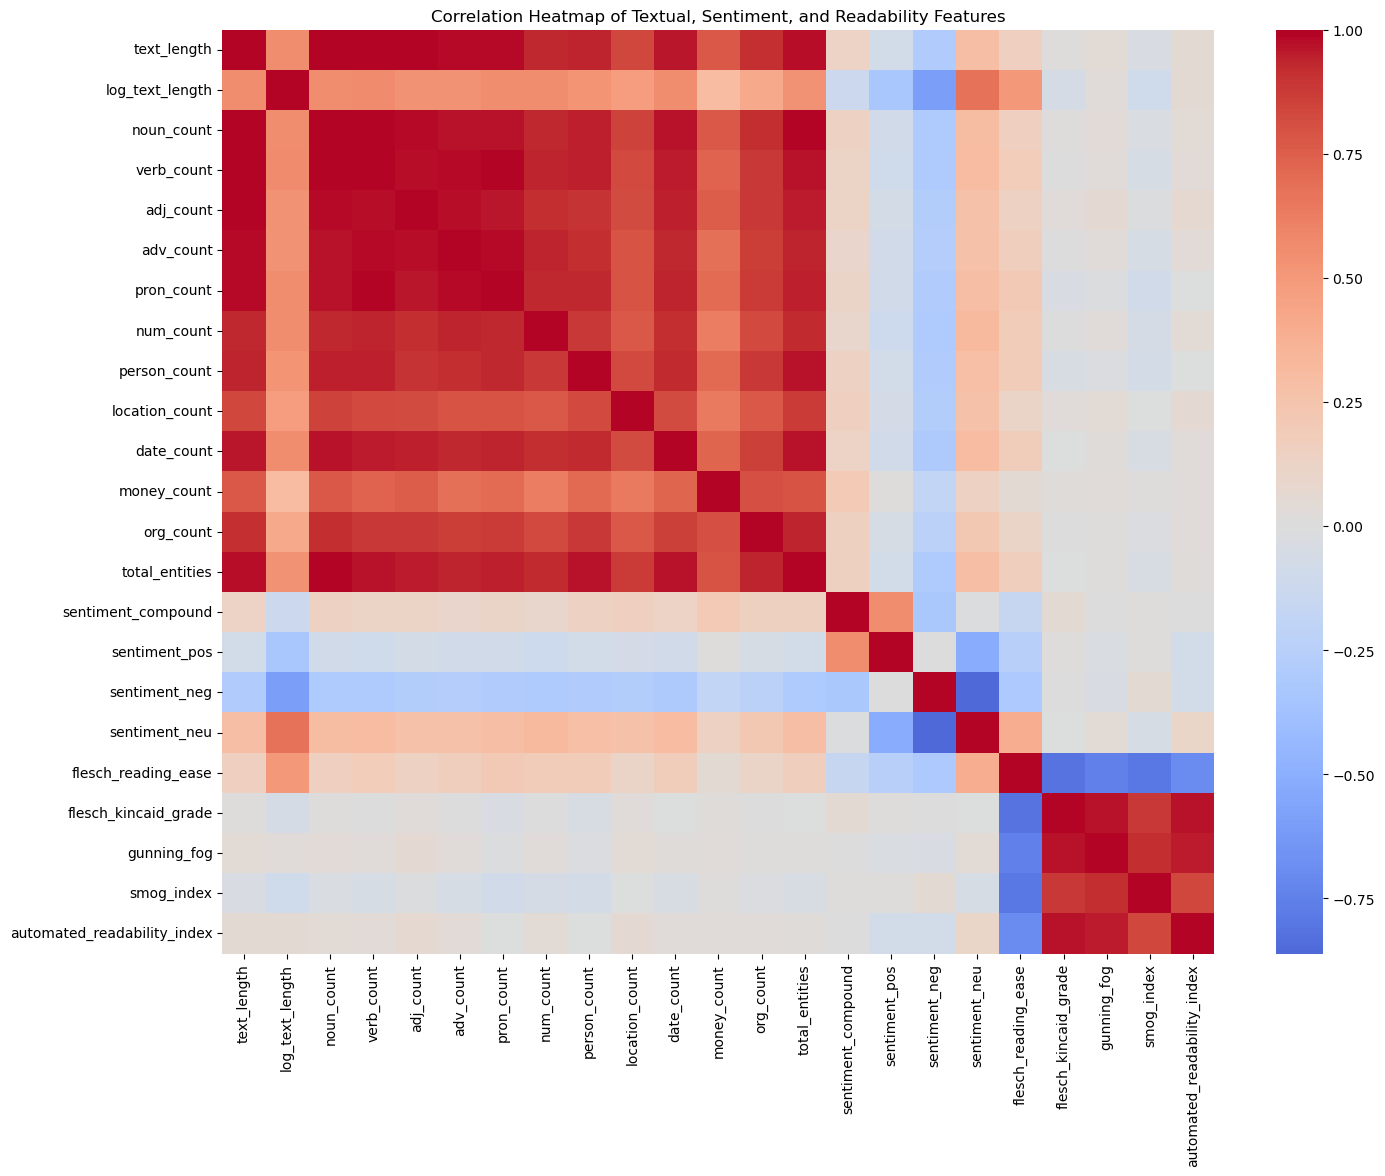

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'text_length', 'log_text_length', 'noun_count', 'verb_count', 'adj_count', 'adv_count', 'pron_count', 'num_count',
    'person_count', 'location_count', 'date_count', 'money_count', 'org_count', 'total_entities',
    'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu',
    'flesch_reading_ease', 'flesch_kincaid_grade', 'gunning_fog', 'smog_index', 'automated_readability_index'
]

plt.figure(figsize=(16,12))
corr = df_timestamp[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Textual, Sentiment, and Readability Features')
plt.show()

- `text_length` positively correlates with `noun_count`, `verb_count`, and `total_entities`.
- Readability metrics (`gunning_fog`, `smog_index`) correlate negatively with `flesch_reading_ease` as expected.
- Sentiment scores are largely uncorrelated with text length or readability.
- Linguistic complexity and entity mentions may reflect trial seriousness.

### Multivariate Analysis of Sentiment, Readability, and Punishment
We explore how text sentiment and readability jointly relate to punishment severity.

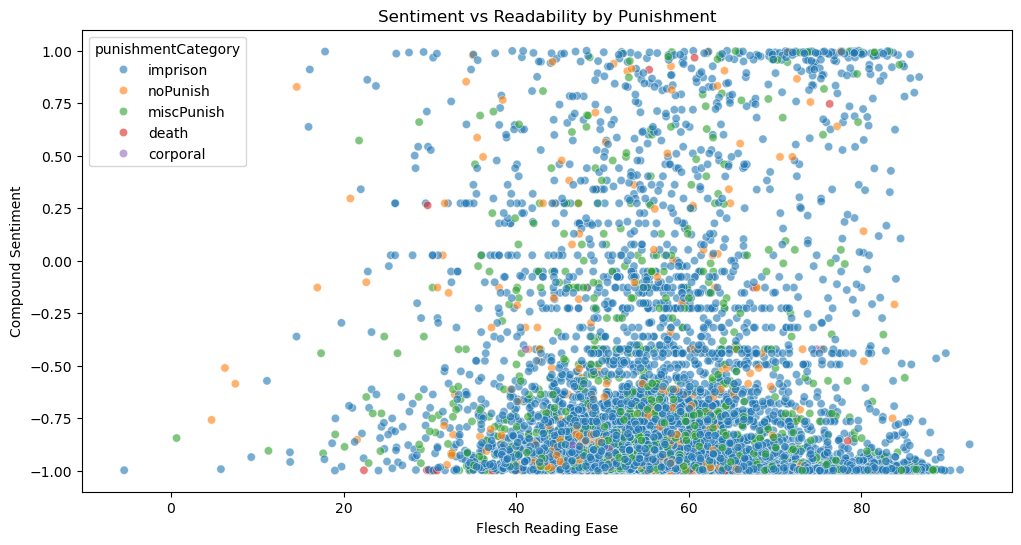

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_timestamp,
    x='flesch_reading_ease',
    y='sentiment_compound',
    hue='punishmentCategory',
    alpha=0.6
)
plt.title('Sentiment vs Readability by Punishment')
plt.xlabel('Flesch Reading Ease')
plt.ylabel('Compound Sentiment')
plt.show()

- Severe punishments tend to cluster in more complex texts with neutral or slightly negative sentiment.
- Minor punishments occur in simpler, shorter trials.
- Joint multivariate analysis reveals relationships invisible in univariate analysis.

### Topic Modeling & Punishment Clustering
Using topic probabilities (`topic_0_prob` … `topic_9_prob`), we cluster trials to identify **groups of offences** and associate them with punishments.

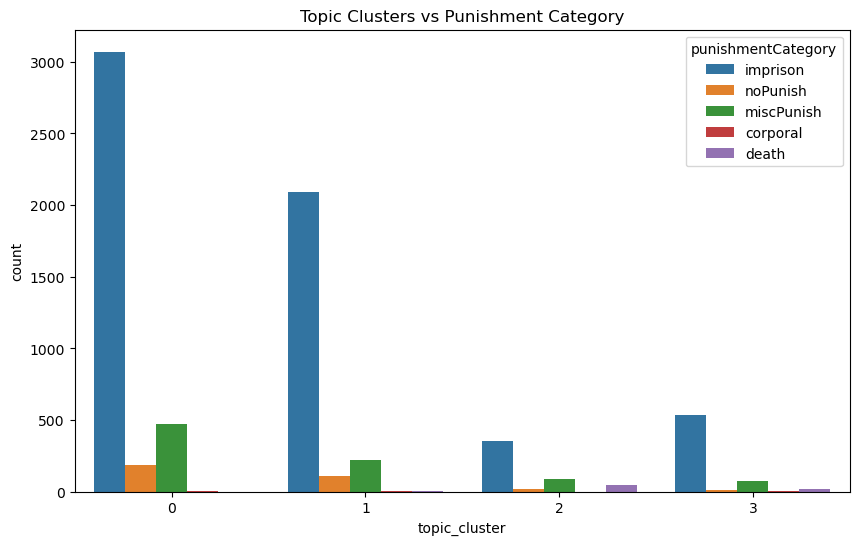

In [ ]:
from sklearn.cluster import KMeans

topic_cols = [f'topic_{i}_prob' for i in range(10)]
X_topics = df_timestamp[topic_cols].fillna(0)

kmeans = KMeans(n_clusters=4, random_state=42)
df_timestamp['topic_cluster'] = kmeans.fit_predict(X_topics)

plt.figure(figsize=(10,6))
sns.countplot(data=df_timestamp, x='topic_cluster', hue='punishmentCategory')
plt.title('Topic Clusters vs Punishment Category')
plt.show()

- Certain topic clusters correspond to violent offences and severe punishments.
- Other clusters represent minor offences with lighter punishments.
- Topic modeling combined with clustering reveals latent patterns not directly visible in the categorical columns.

## Network Analysis of Defendants and Victims
Using `defendantNames` and `victimNames`, we can create a network graph of trial interactions.
This reveals multi-defendant or multi-victim trials, co-offending patterns, and influential actors.

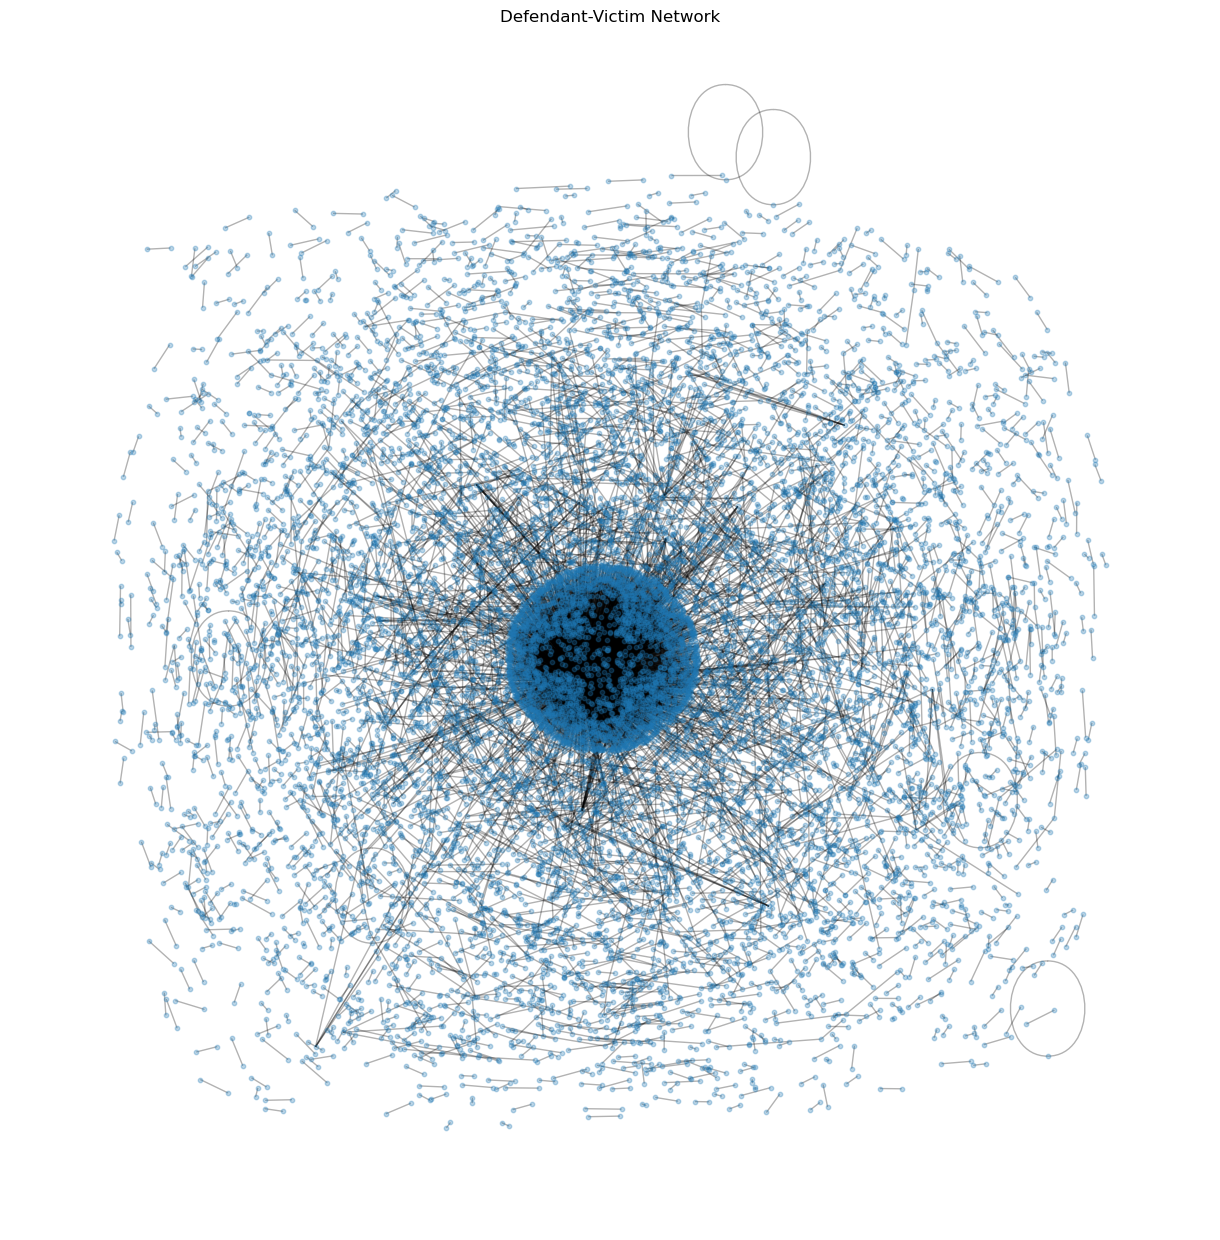

In [ ]:
import networkx as nx

G = nx.Graph()
for _, row in df_timestamp.iterrows():
    defendants = str(row['defendantNames']).split(';')
    victims = str(row['victimNames']).split(';')
    for d in defendants:
        for v in victims:
            G.add_edge(d.strip(), v.strip())

plt.figure(figsize=(12,12))
nx.draw(G, node_size=10, alpha=0.3)
plt.title('Defendant-Victim Network')
plt.show()

### PCA patterns

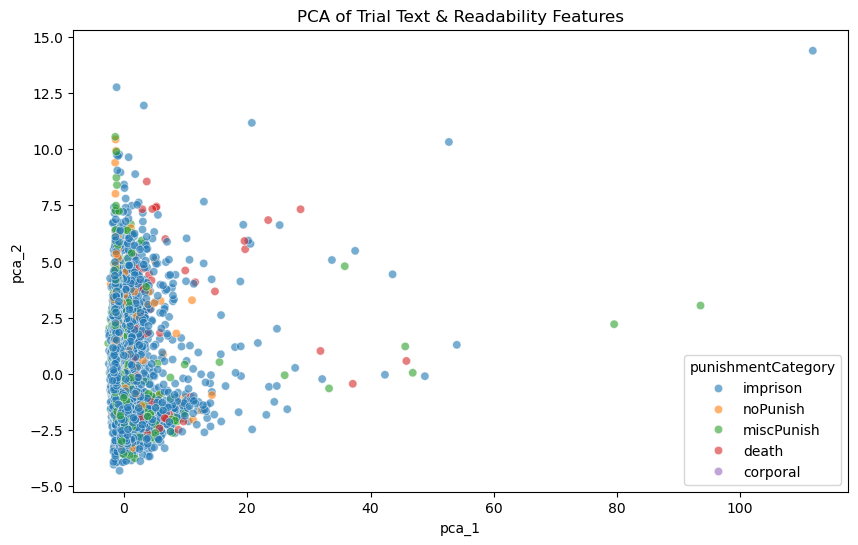

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_features = numeric_cols
X = df_timestamp[pca_features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_timestamp['pca_1'] = components[:,0]
df_timestamp['pca_2'] = components[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_timestamp, x='pca_1', y='pca_2', hue='punishmentCategory', alpha=0.6)
plt.title('PCA of Trial Text & Readability Features')
plt.show()

- Some defendants appear in multiple trials (high-degree nodes), indicating repeat offenders.
- Multi-defendant trials form connected components.
- Network structure provides deeper relational insight beyond individual columns
1. **Text Complexity & Punishment**: Longer, more complex trial texts correspond to severe punishments; simpler texts correspond to minor offences.
2. **Topic Clusters**: Topic modeling reveals latent groupings of offences; clusters align with severity and type of crime.
3. **Sentiment-Readability Interaction**: Neutral sentiment combined with complex readability metrics indicates serious trials.
4. **PCA Patterns**: Multivariate linguistic features cluster trials by punishment type.
5. **Network Analysis**: Defendant-victim relationships highlight co-offending, repeat offenders, and multi-defendant trials.
6. **Gender-Text Interactions**: Male defendants dominate complex trial texts and violent offences; female defendants cluster in minor offences.
7. **Entity & POS Features**: High entity counts and noun-heavy texts correlate with complex, severe trials.

Below questioned has been answered through EDA
1. Gender & Crime

What is the distribution of defendant gender in the dataset?

How has the gender-crime relationship changed over the years?

Are certain offence categories dominated by male or female defendants?

How does punishment type vary by defendant gender?

Do female and male defendants differ in trial text length or complexity?

2️. Offence & Punishment Analysis

What are the most frequent offence categories?

What are the most frequent punishment categories?

How are punishments distributed by offence type?

What is the guilty vs not guilty verdict distribution?

How do offence and punishment interact in multivariate space?

3️. Textual Analysis

What is the distribution of trial text lengths?

What is the distribution of POS tags (nouns, verbs, adjectives, etc.)?

What is the distribution of named entities (persons, organizations, locations, dates, money)?

How do readability metrics (Flesch, Gunning Fog, SMOG, ARI) vary across trials?

How does sentiment vary across trial texts?

Are there correlations between text length, readability, sentiment, and entities?

4️. Topic Modeling & Latent Features

What are the dominant topics in trial texts?

How do dominant topics differ by gender?

Can we cluster trials based on topic probabilities and link them to punishment severity?

5️. Multivariate & Interaction Insights

How do text complexity, sentiment, and punishment interact?

How do linguistic features and entity counts correlate with punishment or offence type?

Can PCA reveal latent clusters of trials by text features and readability?

Are there distinct clusters of trials with severe vs minor punishments based on linguistic and topic features?

6️. Network & Relational Analysis

What is the network structure of defendants and victims?

Are there repeat offenders or multi-defendant trials visible in the network?

Do clusters in the defendant-victim network correspond to certain offence or punishment types?

7️. Sentiment & Topic Interaction

Does sentiment vary by offence type, punishment, or gender?

Do topic clusters align with sentiment or readability patterns?